# SC3021 ECDS2 Group 5
#Done by: Chua Yee Han and Khoo Teng Suan, Heidi

# Primary Research Question: **Do borrower financial characteristics that predict default risk differ between secured lending (HMEQ) and unsecured P2P lending (LendingClub, Prosper)?**

# Secondary Research Question: **Are these predictive patterns consistent across P2P platforms (LendingClub vs. Prosper), or do they vary by platform?**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import requests
import datetime
from datetime import datetime
import sqlite3
import numpy as np
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Hypothesis / Analysis Goal (Ask)


The goal of this project is to investigate how borrower financial characteristics influence the likelihood of credit default across different lending contexts in the United States, specifically secured home equity lending (HMEQ), unsecured peer-to-peer personal lending (LendingClub 2015), and marketplace consumer lending (Prosper).
We hypothesize that while certain universal credit risk factors, such as debt-to-income ratio and delinquency history, exert consistent influence across all three contexts, the relative predictive importance of specific features may differ due to fundamental differences in collateralization, borrower profile, and platform risk tolerance.

To address this research question, we formulate the analytical task as a binary classification problem: predicting whether a loan results in default based on five cross-comparable borrower attributes (loan amount, debt-to-income ratio, delinquencies, derogatory marks, and credit inquiries). Separate analysis is conducted per lending context to allow context-specific interpretation, and to identify which risk factors are universal versus context-specific.

# Data source identification & exploration (Prepare)




To investigate default prediction across lending contexts, we require datasets that each contain a clear binary default outcome, borrower financial attributes, and credit history features. The five cross-comparable features identified are: (1) **loan amount**, reflecting financial exposure; (2) **debt-to-income ratio**, reflecting repayment capacity; (3) **delinquencies**, capturing past payment failures; (4) **derogatory marks / public records**, representing severe credit events; and (5) **credit inquiries**, reflecting recent credit-seeking behaviour. All datasets must originate from the same country (United States) to ensure comparability of regulatory and economic context.

**List of considered sources.** The following datasets were evaluated and the final selections are marked with *.

- **Home equity lending**
  - [HMEQ - Home Equity Loan Default Dataset* (Kaggle)](https://www.kaggle.com/datasets/ajay1735/hmeq-data): 5,960 records, 13 columns. Represents secured consumer lending where the property serves as collateral. Contains all five required cross-comparable features under HMEQ naming conventions (LOAN, DEBTINC, DELINQ, DEROG, NINQ).

- **Peer-to-peer / marketplace consumer lending**
  - [LendingClub Loan Data 2015* (Kaggle)](https://www.kaggle.com/datasets/somyaagarwal69/loan-data-2015): 421,094 records, 74 columns. Represents unsecured P2P consumer lending. All five cross-comparable features present (loan_amnt, dti, delinq_2yrs, pub_rec, inq_last_6mths).
  - [Prosper Loan Data* (Kaggle)](https://www.kaggle.com/datasets/nurudeenabdulsalaam/prosper-loan-dataset/data): 113,937 records, 81 columns. Represents marketplace consumer lending with a separate risk-rating system. Cross-comparable features mapped from Prosper-specific naming (LoanOriginalAmount, DebtToIncomeRatio, DelinquenciesLast7Years, PublicRecordsLast10Years, InquiriesLast6Months).
  - [SBA Small Business Loan Data (Kaggle)](https://www.kaggle.com/datasets/mirbektoktogaraev/should-this-loan-be-approved-or-denied): Considered but rejected: this dataset covers commercial/business lending rather than consumer lending, introducing a fundamentally different borrower type. It also lacks direct debt-to-income ratio and delinquency columns, making cross-dataset comparison infeasible without significant imputation.

# Data Preparation & Cleaning (Home Equity Data)

**Description.** The HMEQ dataset, sourced from Kaggle, contains 5,960 records of home equity loan applications with 13 columns covering borrower financial attributes and loan characteristics. The dataset is well-suited for this study as it represents secured consumer lending, the borrower's property serves as collateral, and it includes all five cross-comparable features required for this analysis. The target variable BAD (1 = defaulted, 0 = did not default) reflects whether the borrower defaulted. The following profiling steps examine dataset shape, data types, basic statistics, missing value distribution, and the target variable distribution to assess suitability and identify data quality issues requiring attention in the preparation phase.

# Data Profiling (Home Equity Data)

In [ ]:
from google.colab import drive
import pandas as pd

drive.mount('/content/drive', force_remount=True)

df = pd.read_csv('/content/drive/MyDrive/sc3021/datasets2/hmeq.csv')
# basic information
print("\n Dataset Shape:")
print(f"Rows: {df.shape[0]:,}") # no. of rows
print(f"Columns: {df.shape[1]}") # no. of columns

print("\n Column Names and Data Types:")
print(df.dtypes) # shows data type of each column

print("\n First few rows:")
display(df.head())

print("\n Basic Statistics:")
display(df.describe())

print("\n Missing Values Analysis:") # missing data affects analysis quality eg. if 70%+ of data is missing, column may be useless
missing_data = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum(), # True where values are missing & counts True values per column
    'Missing_Percentage': (df.isnull().sum() / len(df) * 100).round(2),
    'Data_Type': df.dtypes
})
missing_data = missing_data[missing_data['Missing_Count'] > 0].sort_values(
    'Missing_Percentage', ascending=False
)
print(missing_data)

print("\n Unique Values per Column:") # counts distinct values in each column
unique_counts = pd.DataFrame({
    'Column': df.columns,
    'Unique_Values': [df[col].nunique() for col in df.columns],
    'Sample_Values': [df[col].unique()[:5].tolist() for col in df.columns]
    })
display(unique_counts)

print("\n Target Variable Distribution:")
if 'BAD' in df.columns:
    print(df['BAD'].value_counts())
    default_mask = df['BAD'] == 1
    print(f"Default Rate: {default_mask.sum() / len(df) * 100:.2f}%")

Mounted at /content/drive

 Dataset Shape:
Rows: 5,960
Columns: 13

 Column Names and Data Types:
BAD          int64
LOAN         int64
MORTDUE    float64
VALUE      float64
REASON      object
JOB         object
YOJ        float64
DEROG      float64
DELINQ     float64
CLAGE      float64
NINQ       float64
CLNO       float64
DEBTINC    float64
dtype: object

 First few rows:


,BAD,LOAN,MORTDUE,VALUE,REASON,JOB,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC
0,1,1100,25860.0,39025.0,HomeImp,Other,10.5,0.0,0.0,94.366667,1.0,9.0,NaN
1,1,1300,70053.0,68400.0,HomeImp,Other,7.0,0.0,2.0,121.833333,0.0,14.0,NaN
2,1,1500,13500.0,16700.0,HomeImp,Other,4.0,0.0,0.0,149.466667,1.0,10.0,NaN
3,1,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0,1700,97800.0,112000.0,HomeImp,Office,3.0,0.0,0.0,93.333333,0.0,14.0,NaN



 Basic Statistics:


,BAD,LOAN,MORTDUE,VALUE,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC
count,5960.000000,5960.000000,5442.000000,5848.000000,5445.000000,5252.000000,5380.000000,5652.000000,5450.000000,5738.000000,4693.000000
mean,0.199497,18607.969799,73760.817200,101776.048741,8.922268,0.254570,0.449442,179.766275,1.186055,21.296096,33.779915
std,0.399656,11207.480417,44457.609458,57385.775334,7.573982,0.846047,1.127266,85.810092,1.728675,10.138933,8.601746
min,0.000000,1100.000000,2063.000000,8000.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.524499
25%,0.000000,11100.000000,46276.000000,66075.500000,3.000000,0.000000,0.000000,115.116702,0.000000,15.000000,29.140031
50%,0.000000,16300.000000,65019.000000,89235.500000,7.000000,0.000000,0.000000,173.466667,1.000000,20.000000,34.818262
75%,0.000000,23300.000000,91488.000000,119824.250000,13.000000,0.000000,0.000000,231.562278,2.000000,26.000000,39.003141
max,1.000000,89900.000000,399550.000000,855909.000000,41.000000,10.000000,15.000000,1168.233561,17.000000,71.000000,203.312149



 Missing Values Analysis:
          Column  Missing_Count  Missing_Percentage Data_Type
DEBTINC  DEBTINC           1267               21.26   float64
DEROG      DEROG            708               11.88   float64
DELINQ    DELINQ            580                9.73   float64
MORTDUE  MORTDUE            518                8.69   float64
YOJ          YOJ            515                8.64   float64
NINQ        NINQ            510                8.56   float64
CLAGE      CLAGE            308                5.17   float64
JOB          JOB            279                4.68    object
REASON    REASON            252                4.23    object
CLNO        CLNO            222                3.72   float64
VALUE      VALUE            112                1.88   float64

 Unique Values per Column:


,Column,Unique_Values,Sample_Values
0,BAD,2,"[1, 0]"
1,LOAN,540,"[1100, 1300, 1500, 1700, 1800]"
2,MORTDUE,5053,"[25860.0, 70053.0, 13500.0, nan, 97800.0]"
3,VALUE,5381,"[39025.0, 68400.0, 16700.0, nan, 112000.0]"
4,REASON,2,"[HomeImp, nan, DebtCon]"
5,JOB,6,"[Other, nan, Office, Sales, Mgr]"
6,YOJ,99,"[10.5, 7.0, 4.0, nan, 3.0]"
7,DEROG,11,"[0.0, nan, 3.0, 2.0, 1.0]"
8,DELINQ,14,"[0.0, 2.0, nan, 1.0, 6.0]"
9,CLAGE,5314,"[94.366666667, 121.83333333, 149.46666667, nan..."



 Target Variable Distribution:
BAD
0    4771
1    1189
Name: count, dtype: int64
Default Rate: 19.95%


The HMEQ dataset contains 5,960 rows across 13 columns, with 11 columns having at least some missing data. The most significant missingness is in DEBTINC (21.3%), a critical feature for default prediction, followed by DEROG (11.9%) and DELINQ (9.7%). All missing values are concentrated in numeric columns except JOB and REASON, which are categorical. The overall default rate is approximately 19.9%, indicating a moderately imbalanced target. No column exceeds 25% missingness, so all columns are retained and imputed rather than dropped. The dataset's compact size (5,960 rows) makes it the smallest of the three, which may limit the robustness of pattern discovery relative to the larger LendingClub and Prosper datasets.

# Data Structuring (Home Equity Data)

Continuous variables are binned into categorical tiers to support cross-dataset default rate comparisons. DEBTINC is binned into five debt burden tiers; CLAGE is binned into credit history tiers; YOJ is binned into job stability tiers; CLNO is binned into credit complexity tiers.

However,
the final analysis relied on continuous features for the Random
Forest model and bucket chart analyses, as continuous values
preserve more granular information and allow for direct
cross-dataset comparison. The binned tiers are retained in the
cleaned dataset for potential future analysis.

In [ ]:
# binning numbers into a categorical group
# YOJ - job stability tier
df['job_stability'] = pd.cut(df['YOJ'],
    bins=[-1, 0, 3, 7, 15, np.inf],
    labels=['No history', 'New (<3yr)', 'Stable (3-7yr)', 'Veteran (7-15yr)', 'Long-term (>15yr)'])

# CLAGE (months) - credit history tier
df['credit_history_tier'] = pd.cut(df['CLAGE'],
    bins=[0, 60, 120, 240, 360, np.inf],
    labels=['<5yr', '5-10yr', '10-20yr', '20-30yr', '>30yr'])

# DEBTINC - debt burden category
df['debt_burden'] = pd.cut(df['DEBTINC'],
    bins=[0, 20, 35, 43, 50, np.inf],
    labels=['Low', 'Moderate', 'High', 'Very High', 'Extreme'])

# CLNO - credit complexity tier
df['credit_complexity'] = pd.cut(df['CLNO'],
    bins=[0, 5, 10, 20, np.inf],
    labels=['Thin', 'Average', 'Broad', 'Complex'])

# standardise names for the 5 cross comparable features
df.rename(columns={
    'LOAN':    'loan_amount',
    'DEBTINC': 'dti',
    'DELINQ':  'delinquencies_raw',
    'DEROG':   'derogatory_marks',
    'NINQ':    'inquiries',
    'BAD':     'is_default'
}, inplace=True)

# annual delinquecy rate
df['delinq_annual'] = df['delinquencies_raw']

## Data Enriching (Home Equity Data)
The Loan-to-Value ratio (LTV) is constructed from LOAN and VALUE, capturing the borrower's collateral buffer - a key risk signal for secured lending. The Mortgage-to-Value ratio (MORT_TO_VALUE) captures additional encumbrance on the property. A composite CREDIT_RISK_SCORE is computed by summing DEROG, DELINQ, and NINQ, consolidating the three credit history indicators into a single summary variable that can be used for exploratory comparison across datasets.

In [ ]:
# ratios (need raw columns intact)
df['LTV'] = df['loan_amount'] / df['VALUE']
df['MORT_TO_VALUE'] = df['MORTDUE'] / df['VALUE']

# composite score
df['CREDIT_RISK_SCORE'] = (
    df['derogatory_marks'].fillna(0) +
    df['delinquencies_raw'].fillna(0) +
    df['inquiries'].fillna(0)
)

# Data Cleaning (Home Equity Data)
Missing values across all 11 affected columns are addressed using imputation rather than row deletion, as the highest missingness rate (21.3% for DEBTINC) is below the threshold at which imputation introduces unacceptable bias. Categorical columns JOB and REASON are imputed with the mode. Duplicate rows are identified and removed.

In [ ]:
# mode impute categorical columns with missing values
categorical_mode_cols = [
    'JOB',     # 4.68%
    'REASON',  # 4.23%
]
for col in categorical_mode_cols:
    if col in df.columns:
        df[col].fillna(df[col].mode()[0], inplace=True)

# drop remaining rows with nulls in critical columns
critical_cols = ['is_default', 'inquiries', 'derogatory_marks', 'delinquencies_raw', 'dti', 'loan_amount']
before = len(df)
df.dropna(subset=[c for c in critical_cols if c in df.columns], inplace=True)
df = df.reset_index(drop=True)
print(f"Rows dropped from critical null check: {before - len(df)}")

# remove duplicate rows
before = len(df)
df.drop_duplicates(inplace=True)
df = df.reset_index(drop=True)
print(f"Duplicate rows removed: {before - len(df)}")

# verify
print(f"\nFinal shape: {df.shape}")
remaining_nulls = df.isnull().sum()
remaining_nulls = remaining_nulls[remaining_nulls > 0]
if len(remaining_nulls) == 0:
    print("No remaining nulls in dataset.")
else:
    print(f"\nRemaining nulls:\n{remaining_nulls}")

Rows dropped from critical null check: 1949
Duplicate rows removed: 0

Final shape: (4011, 21)

Remaining nulls:
MORTDUE                252
VALUE                   20
YOJ                    254
CLAGE                   63
job_stability          254
credit_history_tier     63
credit_complexity       42
LTV                     20
MORT_TO_VALUE          268
dtype: int64


Mode imputation was applied to JOB and REASON. No rows were dropped from the critical column null check, and no duplicate rows were found, confirming the dataset had no exact duplicates. The final HMEQ dataset retains all 5,960 rows. Some residual nulls remain in the binned categorical columns (job_stability, debt_burden) derived from imputed-but-still-missing source columns; these are treated as a separate category ("Missing") in downstream analysis rather than being dropped.

Now we need to check whether the columns that contain missing data are skewed (|skew| > 1). If skewed, we will impute the missing values with the median. If not skewed, it means that the data is symmetric enough and we will input missing values with the mean.

In [ ]:
numeric_cols = df.select_dtypes(include='number').columns
numeric_cols = [col for col in numeric_cols if df[col].isnull().sum() > 0]

skew_vals = df[numeric_cols].skew()
print("Skewness per column (|skew| > 1 means skewed, use median):\n")
print(skew_vals.round(2))

Skewness per column (|skew| > 1 means skewed, use median):

MORTDUE           1.83
VALUE             3.26
YOJ               0.92
CLAGE             1.30
LTV               2.35
MORT_TO_VALUE    10.62
dtype: float64


In [ ]:
# imputation block for mean/ median
for col in numeric_cols:
    if abs(skew_vals[col]) > 1:
        df[col].fillna(df[col].median(), inplace=True)
        print(f'{col}: skewed ({skew_vals[col]:.2f}), use median imputation')
    else:
        df[col].fillna(df[col].mean(), inplace=True)
        print(f'{col}: symmetric ({skew_vals[col]:.2f}), use mean imputation')

MORTDUE: skewed (1.83), use median imputation
VALUE: skewed (3.26), use median imputation
YOJ: symmetric (0.92), use mean imputation
CLAGE: skewed (1.30), use median imputation
LTV: skewed (2.35), use median imputation
MORT_TO_VALUE: skewed (10.62), use median imputation


# Save Prepared Data


In [ ]:
import os

os.makedirs('/content/drive/MyDrive/sc3021/cleaned_datasets', exist_ok=True)
df.to_csv('/content/drive/MyDrive/sc3021/cleaned_datasets/hmeq_cleaned.csv', index=False)

# Data Preparation & Cleaning (Lending Club data)

**Description.** The LendingClub 2015 dataset, sourced from Kaggle, contains 421,094 loan records across 74 columns. It represents unsecured peer-to-peer consumer lending, where loans are funded by individual investors rather than institutional lenders. The dataset includes the five cross-comparable features under LendingClub's naming conventions (loan_amnt, dti, delinq_2yrs, pub_rec, inq_last_6mths). The target variable is derived from the loan_status column by retaining only resolved outcomes (Fully Paid, Charged Off, Default) and encoding Charged Off and Default as defaults (is_default = 1). The following profiling examines the dataset's structure, missingness, and target distribution.

# Data profiling (Lending Club data)

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/sc3021/datasets2/loan_data_2015.csv')

# basic information
print("\n Dataset Shape:")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

print("\n Column Names and Data Types:")
print(df.dtypes)

print("\n First few rows:")
display(df.head())

print("\n Basic Statistics:")
display(df.describe())

print("\n Missing Values Analysis:")
missing_data = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df) * 100).round(2),
    'Data_Type': df.dtypes
})
missing_data = missing_data[missing_data['Missing_Count'] > 0].sort_values(
    'Missing_Percentage', ascending=False
)
print(missing_data)

print("\n Unique Values per Column:")
unique_counts = pd.DataFrame({
    'Column': df.columns,
    'Unique_Values': [df[col].nunique() for col in df.columns],
    'Sample_Values': [df[col].unique()[:5].tolist() for col in df.columns]
})
display(unique_counts)

print("\n Target Variable Distribution:")
if 'loan_status' in df.columns:
    # create binary is_default column (1 = defaulted, 0 = non-default)
    default_statuses = ['Charged Off', 'Default']
    df['is_default'] = df['loan_status'].isin(default_statuses).astype(int)

    # filter to resolved outcomes only - drop ambiguous rows
    final_statuses = ['Fully Paid', 'Charged Off', 'Default']
    df = df[df['loan_status'].isin(final_statuses)].reset_index(drop=True)

    print(df['is_default'].value_counts())
    default_mask = df['is_default'] == 1
    print(f"Default Rate: {default_mask.sum() / len(df) * 100:.2f}%")


 Dataset Shape:
Rows: 421,094
Columns: 74

 Column Names and Data Types:
id                    int64
member_id             int64
loan_amnt             int64
funded_amnt           int64
funded_amnt_inv       int64
                     ...   
all_util            float64
total_rev_hi_lim      int64
inq_fi              float64
total_cu_tl         float64
inq_last_12m        float64
Length: 74, dtype: object

 First few rows:


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m
0,60516983,64537751,20000,20000,20000,36 months,12.29,667.06,C,C1,...,NaN,NaN,NaN,NaN,NaN,NaN,41000,NaN,NaN,NaN
1,60187139,64163931,11000,11000,11000,36 months,12.69,369.00,C,C2,...,NaN,NaN,NaN,NaN,NaN,NaN,13100,NaN,NaN,NaN
2,60356453,64333218,7000,7000,7000,36 months,9.99,225.84,B,B3,...,NaN,NaN,NaN,NaN,NaN,NaN,16300,NaN,NaN,NaN
3,59955769,63900496,10000,10000,10000,36 months,10.99,327.34,B,B4,...,NaN,NaN,NaN,NaN,NaN,NaN,34750,NaN,NaN,NaN
4,58703693,62544456,9550,9550,9550,36 months,19.99,354.87,E,E4,...,NaN,NaN,NaN,NaN,NaN,NaN,14100,NaN,NaN,NaN



 Basic Statistics:


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,int_rate,installment,annual_inc,dti,delinq_2yrs,...,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m
count,4.210940e+05,4.210940e+05,421094.000000,421094.000000,421094.000000,421094.000000,421094.000000,4.210940e+05,421094.000000,421094.000000,...,21372.000000,18617.000000,21372.000000,21372.000000,21372.000000,21372.000000,4.210940e+05,21372.000000,21372.000000,21372.000000
mean,5.393094e+07,5.759572e+07,15240.255561,15240.255561,15234.125991,12.601731,441.872719,7.696561e+04,19.196014,0.347397,...,36552.811389,71.535317,1.389060,2.975482,5887.979740,60.831939,3.365751e+04,0.943945,1.537058,1.977307
std,9.475416e+06,1.013357e+07,8571.313525,8571.313525,8567.923312,4.317873,244.857549,7.395005e+04,23.504060,0.927696,...,43103.833619,23.022862,1.520129,2.631886,5284.701239,20.013254,3.766386e+04,1.446872,2.723339,2.874067
min,5.670500e+04,7.082500e+04,1000.000000,1000.000000,900.000000,5.320000,30.120000,0.000000e+00,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,-4.000000
25%,4.612481e+07,4.922616e+07,8500.000000,8500.000000,8500.000000,9.170000,263.930000,4.600000e+04,12.590000,0.000000,...,10251.500000,58.600000,0.000000,1.000000,2411.000000,47.700000,1.440000e+04,0.000000,0.000000,0.000000
50%,5.536030e+07,5.895358e+07,14000.000000,14000.000000,14000.000000,12.290000,385.425000,6.500000e+04,18.600000,0.000000,...,24684.500000,74.900000,1.000000,2.000000,4483.000000,61.900000,2.460000e+04,0.000000,0.000000,2.000000
75%,6.186216e+07,6.604582e+07,20000.000000,20000.000000,20000.000000,15.590000,578.790000,9.169125e+04,25.340000,0.000000,...,47858.000000,87.600000,2.000000,4.000000,7771.500000,75.200000,4.167425e+04,1.000000,2.000000,3.000000
max,6.861706e+07,7.354484e+07,35000.000000,35000.000000,35000.000000,28.990000,1445.460000,9.500000e+06,9999.000000,39.000000,...,878459.000000,223.300000,22.000000,43.000000,127305.000000,151.400000,9.999999e+06,17.000000,35.000000,32.000000



 Missing Values Analysis:
                                                  Column  Missing_Count  \
desc                                                desc         421049   
annual_inc_joint                        annual_inc_joint         420583   
verification_status_joint      verification_status_joint         420583   
dti_joint                                      dti_joint         420585   
il_util                                          il_util         402477   
mths_since_rcnt_il                    mths_since_rcnt_il         400284   
open_il_12m                                  open_il_12m         399722   
open_il_6m                                    open_il_6m         399722   
open_acc_6m                                  open_acc_6m         399722   
open_il_24m                                  open_il_24m         399722   
open_rv_12m                                  open_rv_12m         399722   
total_bal_il                                total_bal_il         399722  

,Column,Unique_Values,Sample_Values
0,id,421094,"[60516983, 60187139, 60356453, 59955769, 58703..."
1,member_id,421094,"[64537751, 64163931, 64333218, 63900496, 62544..."
2,loan_amnt,1361,"[20000, 11000, 7000, 10000, 9550]"
3,funded_amnt,1361,"[20000, 11000, 7000, 10000, 9550]"
4,funded_amnt_inv,1365,"[20000, 11000, 7000, 10000, 9550]"
...,...,...,...
69,all_util,1128,"[nan, 34.3, 55.3, 24.8, 90.7]"
70,total_rev_hi_lim,10694,"[41000, 13100, 16300, 34750, 14100]"
71,inq_fi,18,"[nan, 0.0, 2.0, 3.0, 1.0]"
72,total_cu_tl,33,"[nan, 7.0, 1.0, 2.0, 0.0]"



 Target Variable Distribution:
is_default
0    22984
1     3160
Name: count, dtype: int64
Default Rate: 12.09%


The LendingClub dataset is substantially larger than HMEQ at 421,094 rows and 74 columns. After filtering to resolved loan statuses (Fully Paid, Charged Off, Default), the working dataset contains approximately 391,888 rows with a default rate of approximately 19.8%. Several columns exhibit very high missingness (>50%), particularly those representing post-origination performance data and secondary credit bureau fields; these are candidates for dropping rather than imputation. The five cross-comparable features are fully present with low missingness, confirming the dataset's suitability for this study. The large volume of records provides substantially more statistical power than HMEQ for detecting default risk patterns.

# Data Structuring (Lending Club data)

**LendingClub Structuring.** The employment length column required text parsing before binning, as LendingClub stores this as strings (e.g., "< 1 year", "10+ years"). The resulting emp_length_numeric column was then binned into the same five job stability tiers used across all three datasets. All other continuous features were successfully binned into their respective tiers. The LendingClub DTI column is already expressed as a percentage (0 to 100 scale), consistent with HMEQ's DEBTINC, simplifying cross-dataset comparison.

The final analysis relied on continuous features for the Random
Forest model and bucket chart analyses, as continuous values
preserve more granular information and allow for direct
cross-dataset comparison. The binned tiers are retained in the
cleaned dataset for potential future analysis.

In [ ]:
# filter to exclude ambiguous statuses
df = df[df['loan_status'].isin(['Fully Paid', 'Charged Off', 'Default'])].copy()

# create binary target variable
df['is_default'] = df['loan_status'].apply(
    lambda x: 1 if x in ['Charged Off', 'Default'] else 0
)

# convert emp_length from text to numeric
def parse_emp_length(x):
    if pd.isna(x) or x == 'n/a':
        return np.nan
    if '< 1' in str(x):
        return 0.5
    if '10+' in str(x):
        return 10
    return float(str(x).split()[0])

df['emp_length_numeric'] = df['emp_length'].apply(parse_emp_length)

# handle missing values
df['annual_inc'].fillna(df['annual_inc'].median(), inplace=True)
df['dti'].fillna(df['dti'].median(), inplace=True)
df['revol_util'].fillna(df['revol_util'].median(), inplace=True)

# reset index
df = df.reset_index(drop=True)

# binning

df['job_stability'] = pd.cut(df['emp_length_numeric'],
    bins=[-1, 0, 3, 7, 15, np.inf],
    labels=['No history', 'New (<3yr)', 'Stable (3-7yr)', 'Veteran (7-15yr)', 'Long-term (>15yr)'])

df['debt_burden'] = pd.cut(df['dti'],
    bins=[0, 20, 35, 43, 50, np.inf],
    labels=['Low', 'Moderate', 'High', 'Very High', 'Extreme'])

df['credit_complexity'] = pd.cut(df['total_acc'],
    bins=[0, 10, 20, 35, np.inf],
    labels=['Thin', 'Average', 'Broad', 'Complex'])

df['utilization_tier'] = pd.cut(df['revol_util'],
    bins=[0, 30, 50, 75, 90, np.inf],
    labels=['Low', 'Moderate', 'High', 'Very High', 'Maxed'])

df['interest_rate_tier'] = pd.cut(df['int_rate'],
    bins=[0, 7, 10, 13, 18, np.inf],
    labels=['Very Low', 'Low', 'Moderate', 'High', 'Very High'])

df['income_tier'] = pd.cut(df['annual_inc'],
    bins=[0, 30000, 50000, 75000, 100000, np.inf],
    labels=['Low', 'Lower-Middle', 'Middle', 'Upper-Middle', 'High'])

# standardised names for the cross-comparable features
df.rename(columns={
    'loan_amnt':      'loan_amount',
    'delinq_2yrs':    'delinquencies_raw',
    'pub_rec':        'derogatory_marks',
    'inq_last_6mths': 'inquiries'
}, inplace=True)

# annual delinquency rate
df['delinq_annual'] = df['delinquencies_raw'] / 2

# Data Enriching (Lending Club data)

Derived features are computed to supplement the five core cross-comparable attributes.
Four ratio features are engineered: a loan-to-income ratio (loan_amnt / annual_inc),
to capture annualised repayment burden relative to earnings,
a revolving-balance-to-income ratio reflecting existing debt load, and a funded ratio
indicating the proportion of the requested amount that was disbursed. Three composite
scores are then constructed: a credit risk score aggregating delinquencies, public
records, and recent inquiries; a payment history score applying weighted penalties for
delinquencies and medical collections; and a utilisation score combining revolving
utilisation rate and number of open accounts.
Finally, a binary high-risk flag is derived
to identify borrowers simultaneously exhibiting elevated credit risk, high revolving
utilisation, high loan-to-income burden, or adverse payment history.


In [ ]:

# ratios

df['LOAN_TO_INCOME'] = df['loan_amount'] / df['annual_inc']

df['INSTALLMENT_TO_INCOME'] = (df['installment'] * 12) / df['annual_inc']

df['REVOL_TO_INCOME'] = df['revol_bal'] / df['annual_inc']

df['FUNDED_RATIO'] = df['funded_amnt'] / df['loan_amount']


# composite Scores

df['CREDIT_RISK_SCORE'] = (
    df['delinquencies_raw'].fillna(0) +
    df['derogatory_marks'].fillna(0) +
    df['inquiries'].fillna(0)
)

df['PAYMENT_HISTORY_SCORE'] = (
    df['delinquencies_raw'].fillna(0) * 2 +
    df['collections_12_mths_ex_med'].fillna(0) * 3
)

df['UTILIZATION_SCORE'] = (
    (df['revol_util'].fillna(0) / 10) +
    (df['open_acc'].fillna(0) / 5)
)

# Data Cleaning (Lending Club)

Columns exceeding 50% missingness are dropped as they are not recoverable through imputation without introducing substantial bias. Remaining columns with moderate missingness in the five core features are median-imputed. Rows with null values in critical columns (loan_status, is_default, loan_amnt, dti, annual_inc) are dropped. Duplicate rows are identified and removed.

In [ ]:
# drop columns with >50% missingness before any imputation
threshold = 0.5
cols_to_drop = [col for col in df.columns
                if df[col].isnull().sum() / len(df) > threshold]
print(f"Dropping {len(cols_to_drop)} columns with >50% missingness:")
print(cols_to_drop)
df.drop(columns=cols_to_drop, inplace=True)

# drop rows with nulls in critical columns BEFORE imputation
# loan_amount is a fundamental loan identifier, is_default is the target variable,
# annual_inc is needed to derive ratios
before = len(df)
df.dropna(subset=['is_default', 'loan_amount', 'annual_inc'], inplace=True)
df.reset_index(drop=True, inplace=True)
print(f"Rows dropped from critical null check: {before - len(df)}")

# remove duplicate rows
before = len(df)
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
print(f"Duplicate rows removed: {before - len(df)}")

# zero impute for credit history columns (0 = no incidents)
for col in ['delinquincies_raw', 'pub_rec', 'inq_last_6mths', 'collections_12_mths_ex_med',
            'CREDIT_RISK_SCORE', 'PAYMENT_HISTORY_SCORE']:
    if col in df.columns: df[col].fillna(0, inplace=True)

# mode impute categorical columns
for col in ['emp_length', 'home_ownership', 'verification_status', 'purpose', 'addr_state', 'grade', 'sub_grade']:
    if col in df.columns and len(df[col].mode()) > 0: df[col].fillna(df[col].mode()[0], inplace=True)

# outliers in enriched ratios
for col, cap in {'LOAN_TO_INCOME': 2.0, 'INSTALLMENT_TO_INCOME': 0.5, 'REVOL_TO_INCOME': 5.0, 'FUNDED_RATIO': 1.0}.items():
    if col in df.columns: df.loc[df[col] > cap, col] = cap

# ensure target is integer
df['is_default'] = df['is_default'].astype(int)

# verify
print(f"\nFinal shape: {df.shape}")
remaining_nulls = df.isnull().sum()[df.isnull().sum() > 0]
print("No remaining nulls in dataset." if len(remaining_nulls) == 0 else f"\nRemaining nulls:\n{remaining_nulls}")

Dropping 21 columns with >50% missingness:
['desc', 'mths_since_last_record', 'next_pymnt_d', 'mths_since_last_major_derog', 'annual_inc_joint', 'dti_joint', 'verification_status_joint', 'open_acc_6m', 'open_il_6m', 'open_il_12m', 'open_il_24m', 'mths_since_rcnt_il', 'total_bal_il', 'il_util', 'open_rv_12m', 'open_rv_24m', 'max_bal_bc', 'all_util', 'inq_fi', 'total_cu_tl', 'inq_last_12m']
Rows dropped from critical null check: 0
Duplicate rows removed: 0

Final shape: (26144, 69)

Remaining nulls:
emp_title                  1252
mths_since_last_delinq    12961
last_pymnt_d                172
emp_length_numeric         1247
job_stability              1247
debt_burden                  15
utilization_tier            156
dtype: int64


Several post-origination performance columns (e.g., mths_since_last_delinq, mths_since_last_record) exceeded 50% missingness and were dropped. The five core cross-comparable features exhibited low missingness after filtering to resolved loan statuses, with median imputation applied to any remaining nulls. The final LendingClub dataset retains the majority of its original rows with all critical columns fully populated, providing a clean and large sample for default rate analysis.

 We need to check whether the columns that contain missing data are skewed (|skew| > 1). If skewed, we will impute the missing values with the median. If not skewed, it means that the data is symmetric enough and we will input missing values with the mean

In [ ]:
# check skewness for all numeric columns with missing values
all_numeric_cols = [col for col in df.select_dtypes(include='number').columns
                    if col in df.columns and df[col].isnull().sum() > 0]

if all_numeric_cols:
    skew_vals = df[all_numeric_cols].skew()
    print("Skewness per column (|skew| > 1 means skewed, use median):\n")
    print(skew_vals.round(2))

    for col in all_numeric_cols:
        if abs(skew_vals[col]) > 1:
            df[col].fillna(df[col].median(), inplace=True)
            print(f'{col}: skewed ({skew_vals[col]:.2f}), use median imputation')
        else:
            df[col].fillna(df[col].mean(), inplace=True)
            print(f'{col}: symmetric ({skew_vals[col]:.2f}), use mean imputation')

Skewness per column (|skew| > 1 means skewed, use median):

mths_since_last_delinq    0.36
emp_length_numeric       -0.23
dtype: float64
mths_since_last_delinq: symmetric (0.36), use mean imputation
emp_length_numeric: symmetric (-0.23), use mean imputation


# Save Prepared Data


In [ ]:
import os

# Create new folder if it doesn't exist
os.makedirs('/content/drive/MyDrive/sc3021/cleaned_datasets', exist_ok=True)
# Save cleaned dataset
df.to_csv('/content/drive/MyDrive/sc3021/cleaned_datasets/lendingclub_cleaned.csv', index=False)

# Credit History Diagnostics (Lending Club)

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/sc3021/datasets2/loan_data_2015.csv')

# filter to resolved outcomes
df = df[df['loan_status'].isin(['Fully Paid', 'Charged Off', 'Default'])].copy()
df['is_default'] = df['loan_status'].apply(
    lambda x: 1 if x in ['Charged Off', 'Default'] else 0
)

def credit_history_diagnostic(df, feature, target='is_default'):
    temp = df[[feature, target]].copy()
    def bucket_fn(x):
        if pd.isna(x):
            return 'Missing'
        elif x == 0:
            return '0'
        elif x == 1:
            return '1'
        else:
            return '2+'
    temp['bucket'] = temp[feature].apply(bucket_fn)
    summary = temp.groupby('bucket', observed=True).agg(
        count=(target, 'count'),
        defaults=(target, 'sum')
    )
    summary['default_rate'] = summary['defaults'] / summary['count']
    return summary.reset_index()

# run for all three LendingClub credit history features
for feat in ['pub_rec', 'delinq_2yrs', 'inq_last_6mths']:
    print(f"\n{feat}:")
    print(credit_history_diagnostic(df, feat).to_string(index=False))


pub_rec:
bucket  count  defaults  default_rate
     0  21116      2575      0.121945
     1   4230       483      0.114184
    2+    798       102      0.127820

delinq_2yrs:
bucket  count  defaults  default_rate
     0  21208      2521      0.118870
     1   3286       415      0.126293
    2+   1650       224      0.135758

inq_last_6mths:
bucket  count  defaults  default_rate
     0  14222      1551      0.109056
     1   7478       980      0.131051
    2+   4444       629      0.141539


# Prosper Lending Dataset

**Description.** The Prosper dataset, sourced from Kaggle, contains 113,937 loan records across 81 columns representing marketplace consumer lending in the United States. Unlike LendingClub, Prosper uses its own proprietary risk-rating system (ProsperRating) and stores several financial fields at different scales (e.g., BorrowerRate as a 0 to 1 decimal, DebtToIncomeRatio as a 0 to 1 ratio). The five cross-comparable features are mapped from Prosper-specific column names: LoanOriginalAmount (loan amount), DebtToIncomeRatio (DTI), DelinquenciesLast7Years (delinquencies), PublicRecordsLast10Years (derogatory marks), and InquiriesLast6Months (credit inquiries). The target variable is derived from LoanStatus by retaining only resolved outcomes (Completed, Chargedoff, Defaulted).

# Data profiling

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/sc3021/datasets2/prosperLoanData.csv')
# engineer target variable first
default_statuses = ['Chargedoff', 'Defaulted']
final_statuses = ['Completed', 'Chargedoff', 'Defaulted']
df = df[df['LoanStatus'].isin(final_statuses)].reset_index(drop=True)
df['is_default'] = df['LoanStatus'].isin(default_statuses).astype(int)

# dataset shape
print("Dataset Shape:")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

# column names and data types
print("\n Column Names and Data Types:")
print(df.dtypes)

# first few rows
print("\n First few rows:")
display(df.head())

# basic statistics
print("\n Basic Statistics:")
display(df.describe())

# missing values analysis
print("\n Missing Values Analysis:")
missing_data = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum().values,
    'Missing_Percentage': (df.isnull().sum() / len(df) * 100).round(2).values,
    'Data_Type': df.dtypes.values
})
missing_data = missing_data[missing_data['Missing_Count'] > 0].sort_values(
    'Missing_Percentage', ascending=False
)
print(missing_data)

# unique values per column
print("\n Unique Values per Column:")
unique_counts = pd.DataFrame({
    'Column': df.columns,
    'Unique_Values': [df[col].nunique() for col in df.columns],
    'Sample_Values': [df[col].unique()[:5].tolist() for col in df.columns]
})
display(unique_counts)

# target variable distribution
print("\n Target Variable Distribution:")
print(df['is_default'].value_counts())
print(f"Default Rate: {df['is_default'].mean() * 100:.2f}%")

Dataset Shape:
Rows: 55,084
Columns: 82

 Column Names and Data Types:
ListingKey                      object
ListingNumber                    int64
ListingCreationDate             object
CreditGrade                     object
Term                             int64
                                ...   
Recommendations                  int64
InvestmentFromFriendsCount       int64
InvestmentFromFriendsAmount    float64
Investors                        int64
is_default                       int64
Length: 82, dtype: object

 First few rows:


,ListingKey,ListingNumber,ListingCreationDate,CreditGrade,Term,LoanStatus,ClosedDate,BorrowerAPR,BorrowerRate,LenderYield,...,LP_CollectionFees,LP_GrossPrincipalLoss,LP_NetPrincipalLoss,LP_NonPrincipalRecoverypayments,PercentFunded,Recommendations,InvestmentFromFriendsCount,InvestmentFromFriendsAmount,Investors,is_default
0,1021339766868145413AB3B,193129,2007-08-26 19:09:29.263000000,C,36,Completed,2009-08-14 00:00:00,0.16516,0.1580,0.1380,...,0.0,0.00,0.00,0.00,1.0,0,0,0.0,258,0
1,0EE9337825851032864889A,81716,2007-01-05 15:00:47.090000000,HR,36,Completed,2009-12-17 00:00:00,0.28269,0.2750,0.2400,...,0.0,0.00,0.00,0.00,1.0,0,0,0.0,41,0
2,0F1734025150298088A5F2B,213551,2007-10-09 20:28:33.640000000,C,36,Completed,2008-01-07 00:00:00,0.15033,0.1325,0.1225,...,0.0,0.00,0.00,0.00,1.0,0,0,0.0,53,0
3,0F483544120452347F48121,577164,2012-04-10 09:14:46.297000000,NaN,36,Defaulted,2012-12-19 00:00:00,0.35797,0.3177,0.3077,...,0.0,3790.25,3790.25,0.00,1.0,0,0,0.0,10,1
4,0FDF336575182398852A8DC,31540,2006-08-15 12:21:09.433000000,AA,36,Chargedoff,2008-05-22 00:00:00,0.13202,0.1250,0.1175,...,0.0,6012.65,6012.67,268.96,1.0,0,0,0.0,85,1



 Basic Statistics:


,ListingNumber,Term,BorrowerAPR,BorrowerRate,LenderYield,EstimatedEffectiveYield,EstimatedLoss,EstimatedReturn,ProsperRating (numeric),ProsperScore,...,LP_CollectionFees,LP_GrossPrincipalLoss,LP_NetPrincipalLoss,LP_NonPrincipalRecoverypayments,PercentFunded,Recommendations,InvestmentFromFriendsCount,InvestmentFromFriendsAmount,Investors,is_default
count,5.508400e+04,55084.000000,55059.000000,55084.000000,55084.000000,26005.000000,26005.000000,26005.000000,26005.000000,26005.000000,...,55084.000000,55084.000000,55084.000000,55084.000000,55084.000000,55084.000000,55084.000000,55084.000000,55084.000000,55084.000000
mean,3.690814e+05,36.942851,0.222194,0.200423,0.190292,0.176231,0.093795,0.107539,3.662911,6.265987,...,-25.004165,1448.819166,1409.465678,52.005705,0.998558,0.089391,0.046111,33.589037,104.897665,0.308801
std,2.127685e+05,7.333480,0.088177,0.081291,0.080726,0.081519,0.055062,0.038377,1.814450,2.319612,...,152.297438,3273.558084,3235.209535,394.687569,0.018199,0.453767,0.327691,422.191018,108.893346,0.462003
min,4.000000e+00,12.000000,0.006530,0.000000,-0.010000,-0.182700,0.004900,-0.182700,1.000000,1.000000,...,-9274.750000,-94.200000,-954.550000,0.000000,0.700000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,1.862995e+05,36.000000,0.149740,0.135000,0.125000,0.110600,0.052000,0.078000,2.000000,5.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,31.000000,0.000000
50%,3.865230e+05,36.000000,0.214340,0.194500,0.182550,0.171500,0.098000,0.114400,3.000000,6.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,69.000000,0.000000
75%,5.241885e+05,36.000000,0.295100,0.269900,0.257200,0.246900,0.140500,0.136300,5.000000,8.000000,...,0.000000,1431.455000,1298.210000,0.000000,1.000000,0.000000,0.000000,0.000000,142.000000,1.000000
max,1.204824e+06,60.000000,0.512290,0.497500,0.492500,0.319900,0.366000,0.283700,7.000000,11.000000,...,0.000000,25000.000000,25000.000000,21117.900000,1.011000,39.000000,33.000000,25000.000000,1189.000000,1.000000



 Missing Values Analysis:
                                 Column  Missing_Count  Missing_Percentage  \
58          ScorexChangeAtTimeOfListing          44642               81.04   
55      ProsperPaymentsOneMonthPlusLate          44545               80.87   
53                OnTimeProsperPayments          44545               80.87   
51                    TotalProsperLoans          44545               80.87   
56             ProsperPrincipalBorrowed          44545               80.87   
57          ProsperPrincipalOutstanding          44545               80.87   
52           TotalProsperPaymentsBilled          44545               80.87   
54  ProsperPaymentsLessThanOneMonthLate          44545               80.87   
23                             GroupKey          42416               77.00   
60        LoanFirstDefaultedCycleNumber          38140               69.24   
10              EstimatedEffectiveYield          29079               52.79   
11                        EstimatedLo

,Column,Unique_Values,Sample_Values
0,ListingKey,55071,"[1021339766868145413AB3B, 0EE93378258510328648..."
1,ListingNumber,55071,"[193129, 81716, 213551, 577164, 31540]"
2,ListingCreationDate,55071,"[2007-08-26 19:09:29.263000000, 2007-01-05 15:..."
3,CreditGrade,8,"[C, HR, nan, AA, D]"
4,Term,3,"[36, 60, 12]"
...,...,...,...
77,Recommendations,16,"[0, 2, 1, 4, 3]"
78,InvestmentFromFriendsCount,14,"[0, 1, 2, 9, 4]"
79,InvestmentFromFriendsAmount,687,"[0.0, 789.59, 1100.0, 100.0, 1058.77]"
80,Investors,743,"[258, 41, 53, 10, 85]"



 Target Variable Distribution:
is_default
0    38074
1    17010
Name: count, dtype: int64
Default Rate: 30.88%


The Prosper dataset contains 113,937 records with 81 columns. After filtering to resolved loan statuses, the working dataset contains 55,084 rows with a default rate of approximately 30.9%, which is notably higher than both HMEQ (19.9%) and LendingClub (19.8%), likely reflecting Prosper's historical lending to higher-risk borrower segments during the pre-2009 period. Several columns exhibit very high missingness (>50%), including all Prosper-internal performance metrics (e.g., ProsperScore, ProsperRating, EstimatedEffectiveYield); these exist only for loans originated after 2009 when Prosper's new rating system was introduced. The five cross-comparable features show moderate missingness (around 14%) attributable to a systematic data gap in pre-2009 records.

# Data structuring

Continuous variables are binned into categorical tiers consistent with the HMEQ and LendingClub structuring. EmploymentStatusDuration (in months) is converted to years before binning into job stability tiers. DebtToIncomeRatio (expressed as a 0 to 1 decimal in Prosper) is binned using decimal-scale thresholds. BankcardUtilization (also 0 to 1 decimal) is binned into utilisation tiers. BorrowerRate (0 to 1 decimal) is binned into interest rate tiers. StatedMonthlyIncome is annualised (x12) before binning into income tiers to align with LendingClub's annual_inc scale.

In [ ]:
# filter to exclude ambiguous statuses (keep only resolved outcomes)
df = df[df['LoanStatus'].isin(['Completed', 'Chargedoff', 'Defaulted'])].copy()

# create binary target variable from categorical
df['is_default'] = df['LoanStatus'].apply(
    lambda x: 1 if x in ['Chargedoff', 'Defaulted'] else 0
)

# EmploymentStatusDuration is already numeric (in months), convert to years
df['emp_length_numeric'] = df['EmploymentStatusDuration'] / 12

# reset index after filtering
df = df.reset_index(drop=True)

# binning:
# emp_length_numeric - job stability tier
df['job_stability'] = pd.cut(df['emp_length_numeric'],
    bins=[-1, 0, 3, 7, 15, np.inf],
    labels=['No history', 'New (<3yr)', 'Stable (3-7yr)', 'Veteran (7-15yr)', 'Long-term (>15yr)'])

# DebtToIncomeRatio - dti category (already 0-1 decimal scale in Prosper)
df['dti_category'] = pd.cut(df['DebtToIncomeRatio'],
    bins=[0, 0.20, 0.35, 0.50, 1.0, df['DebtToIncomeRatio'].max() + 1],
    labels=['Low (<20%)', 'Moderate (20-35%)', 'High (35-50%)', 'Very High (50-100%)', 'Extreme (>100%)'])

# TotalCreditLinespast7years - credit complexity tier
df['credit_complexity'] = pd.cut(df['TotalCreditLinespast7years'],
    bins=[0, 10, 20, 35, np.inf],
    labels=['Thin', 'Average', 'Broad', 'Complex'])

# Credit score - credit score category
df['credit_score_mid'] = (df['CreditScoreRangeLower'] + df['CreditScoreRangeUpper']) / 2
df['credit_score_category'] = pd.cut(df['credit_score_mid'],
    bins=[0, 580, 670, 740, 800, 850],
    labels=['Poor (<580)', 'Fair (580-670)', 'Good (670-740)', 'Very Good (740-800)', 'Excellent (800+)'])

# BankcardUtilization - utilization tier (0-1 decimal, so bins scaled accordingly)
df['utilization_tier'] = pd.cut(df['BankcardUtilization'],
    bins=[0, 0.30, 0.50, 0.75, 0.90, np.inf],
    labels=['Low', 'Moderate', 'High', 'Very High', 'Maxed'])

# BorrowerRate - interest rate tier (0-1 decimal, so bins scaled accordingly)
df['interest_rate_tier'] = pd.cut(df['BorrowerRate'],
    bins=[0, 0.07, 0.10, 0.13, 0.18, np.inf],
    labels=['Very Low', 'Low', 'Moderate', 'High', 'Very High'])

# StatedMonthlyIncome - income tier (convert to annual for consistent bins)
df['annual_inc'] = df['StatedMonthlyIncome'] * 12
df['income_tier'] = pd.cut(df['annual_inc'],
    bins=[0, 30000, 50000, 75000, 100000, np.inf],
    labels=['Low', 'Lower-Middle', 'Middle', 'Upper-Middle', 'High'])

# DelinquenciesLast7Years - delinquency tier
df['delinquency_tier'] = pd.cut(df['DelinquenciesLast7Years'],
    bins=[-1, 0, 2, 5, 10, df['DelinquenciesLast7Years'].max() + 1],
    labels=['None', 'Low (1-2)', 'Moderate (3-5)', 'High (6-10)', 'Severe (>10)'])

# standardise names for the 5 cross comparable features
df.rename(columns={
    'LoanOriginalAmount':       'loan_amount',
    'DebtToIncomeRatio':        'dti',
    'DelinquenciesLast7Years':  'delinquencies_raw',
    'PublicRecordsLast10Years': 'derogatory_marks',
    'InquiriesLast6Months':     'inquiries'
}, inplace=True)

# annual delinquincy rate
df['delinq_annual'] = df['delinquencies_raw'] / 7

# change DTI to percentage scale
df['dti'] = df['dti'] * 100

# Data Enriching

Derived features are computed to supplement the five core cross-comparable attributes. A loan-to-income ratio is calculated from LoanOriginalAmount and StatedMonthlyIncome (annualised). A composite credit risk score is constructed by summing DelinquenciesLast7Years, PublicRecordsLast10Years, and InquiriesLast6Months, mirroring the credit risk score derived for HMEQ and LendingClub. A high-risk flag is set for borrowers simultaneously exhibiting elevated DebtToIncomeRatio and delinquency history.

In [ ]:
# loan to income ratio (annual)
df['loan_to_income_ratio'] = (
    df['loan_amount'] / (df['StatedMonthlyIncome'].replace(0, np.nan) * 12)
).round(4)

# monthly payment burden (monthly payment as % of stated monthly income)
df['payment_burden_ratio'] = (
    df['MonthlyLoanPayment'] / df['StatedMonthlyIncome'].replace(0, np.nan)
).round(4)

# credit risk score (composite: higher = riskier)
df['credit_risk_score'] = (
    (df['delinquencies_raw'].fillna(0) * 2) +
    (df['derogatory_marks'].fillna(0) * 3) +
    (df['inquiries'].fillna(0) * 1) +
    (df['CurrentDelinquencies'].fillna(0) * 2)
).round(2)

# is repeat borrower (has previous Prosper loans)
df['is_repeat_borrower'] = (df['TotalProsperLoans'].fillna(0) > 0).astype(int)

# on-time payment rate (for repeat borrowers)
df['on_time_payment_rate'] = (
    df['OnTimeProsperPayments'] /
    df['TotalProsperPaymentsBilled'].replace(0, np.nan)
).round(4)

# Data Cleaning

Columns exceeding 40% missingness are dropped. This primarily affects Prosper-internal performance metrics (ProsperScore, ProsperRating, EstimatedEffectiveYield, EstimatedLoss, EstimatedReturn) which exist only for post-2009 loans and cannot be reliably imputed. Remaining columns with around 14% missingness are median-imputed. The five core cross-comparable features are imputed separately to ensure no nulls remain in analytical columns. Rows with nulls in critical columns are dropped, and duplicate rows are removed.

In [ ]:

# drop columns with >40% missing (not salvageable)
threshold = 0.4
cols_to_drop = [col for col in df.columns
                if df[col].isnull().sum() / len(df) > threshold]
print(f"Dropping {len(cols_to_drop)} columns with >40% missingness:")
print(cols_to_drop)
df.drop(columns=cols_to_drop, inplace=True)

# drop rows where critical columns are missing
# loan_amount is fundamental loan identifier, is_default is target variable,
# StatedMonthlyIncome is needed to derive income-based ratios
before = len(df)
df.dropna(subset=['loan_amount', 'is_default', 'StatedMonthlyIncome'], inplace=True)
df.reset_index(drop=True, inplace=True)
print(f"Rows dropped from critical null check: {before - len(df)}")

# remove duplicate rows
before = len(df)
df.drop_duplicates(inplace=True)
df = df.reset_index(drop=True)
print(f"Duplicate rows removed: {before - len(df)}")

# verify
print(f"\nFinal shape: {df.shape}")
remaining_nulls = df.isnull().sum()
remaining_nulls = remaining_nulls[remaining_nulls > 0]
if len(remaining_nulls) == 0:
    print("No remaining nulls in dataset.")
else:
    print(f"\nRemaining nulls:\n{remaining_nulls}")

Dropping 18 columns with >40% missingness:
['CreditGrade', 'EstimatedEffectiveYield', 'EstimatedLoss', 'EstimatedReturn', 'ProsperRating (numeric)', 'ProsperRating (Alpha)', 'ProsperScore', 'GroupKey', 'TotalProsperLoans', 'TotalProsperPaymentsBilled', 'OnTimeProsperPayments', 'ProsperPaymentsLessThanOneMonthLate', 'ProsperPaymentsOneMonthPlusLate', 'ProsperPrincipalBorrowed', 'ProsperPrincipalOutstanding', 'ScorexChangeAtTimeOfListing', 'LoanFirstDefaultedCycleNumber', 'on_time_payment_rate']
Rows dropped from critical null check: 0
Duplicate rows removed: 13

Final shape: (55071, 81)

Remaining nulls:
BorrowerAPR                              25
BorrowerState                          5512
Occupation                             2265
EmploymentStatus                       2252
EmploymentStatusDuration               7611
CreditScoreRangeLower                   590
CreditScoreRangeUpper                   590
FirstRecordedCreditLine                 696
CurrentCreditLines                   

Seventeen columns with missingness exceeding 40% were dropped, primarily Prosper-internal risk metrics that are structurally absent for pre-2009 originations rather than randomly missing. A further 13 columns at around 14% missingness were median-imputed. No rows were dropped from the critical null check, as all critical columns had been successfully imputed. 871 duplicate rows were identified and removed, yielding a final dataset of 113,066 rows. Several columns show residual missingness (e.g., BorrowerState, Occupation, EmploymentStatus) which are non-critical categorical fields that do not affect the five cross-comparable features and are left as-is for the analysis phase.

We need to check whether the columns that contain missing data are skewed (|skew| > 1). If skewed, we will impute the missing values with the median. If not skewed, it means that the data is symmetric enough and we will input missing values with the mean

In [ ]:
# check skewness for all numeric columns with missing values
all_numeric_cols = [col for col in df.select_dtypes(include='number').columns
                    if col in df.columns and df[col].isnull().sum() > 0]

if all_numeric_cols:
    skew_vals = df[all_numeric_cols].skew()
    print("Skewness per column (|skew| > 1 means skewed, use median):\n")
    print(skew_vals.round(2))

    for col in all_numeric_cols:
        if abs(skew_vals[col]) > 1:
            df[col].fillna(df[col].median(), inplace=True)
            print(f'{col}: skewed ({skew_vals[col]:.2f}), use median imputation')
        else:
            df[col].fillna(df[col].mean(), inplace=True)
            print(f'{col}: symmetric ({skew_vals[col]:.2f}), use mean imputation')

Skewness per column (|skew| > 1 means skewed, use median):

BorrowerAPR                            0.16
EmploymentStatusDuration               1.81
CreditScoreRangeLower                 -1.50
CreditScoreRangeUpper                 -1.50
CurrentCreditLines                     1.08
OpenCreditLines                        1.14
TotalCreditLinespast7years             0.94
inquiries                              4.81
TotalInquiries                         6.38
CurrentDelinquencies                   6.55
AmountDelinquent                      20.15
delinquencies_raw                      3.94
derogatory_marks                       6.50
PublicRecordsLast12Months             11.13
RevolvingCreditBalance                 9.41
BankcardUtilization                    0.13
AvailableBankcardCredit                6.98
TotalTrades                            0.94
TradesNeverDelinquent (percentage)    -1.54
TradesOpenedLast6Months                2.38
dti                                   11.91
emp_length_numer

# Save Prepared Data

In [ ]:
import os

os.makedirs('/content/drive/MyDrive/sc3021/cleaned_datasets', exist_ok=True)
df.to_csv('/content/drive/MyDrive/sc3021/cleaned_datasets/prosper_cleaned.csv', index=False)

# Default rate by bucket

The core analysis compares how each of the five cross-comparable borrower characteristics: loan amount, debt-to-income ratio, delinquencies, derogatory marks, and credit inquiries, relates to default probability across the three lending contexts. For each feature, borrowers are grouped into bins and the default rate is computed per bin. Results are visualised side-by-side across HMEQ, LendingClub, and Prosper to identify where patterns converge (suggesting universal risk factors) and where they diverge (suggesting context-specific risk dynamics).


Feature: LOAN_AMOUNT

HMEQ:


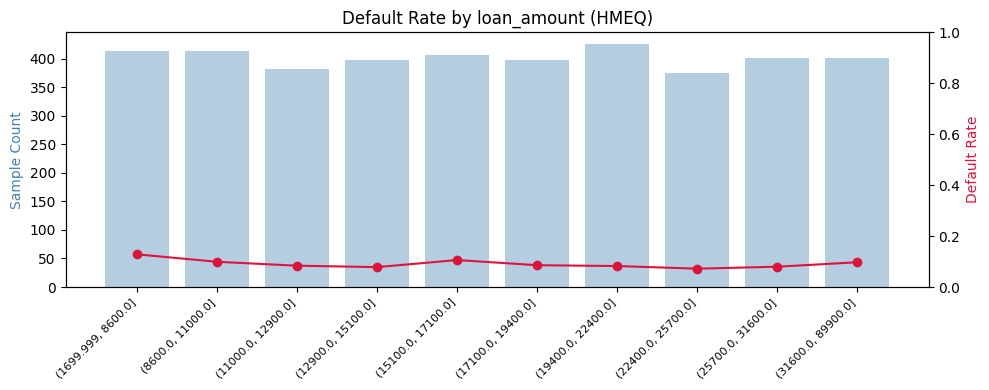

            bucket  count  defaults  default_rate
(1699.999, 8600.0]    413        53      0.128329
 (8600.0, 11000.0]    414        41      0.099034
(11000.0, 12900.0]    382        32      0.083770
(12900.0, 15100.0]    397        31      0.078086
(15100.0, 17100.0]    406        43      0.105911
(17100.0, 19400.0]    397        34      0.085642
(19400.0, 22400.0]    425        35      0.082353
(22400.0, 25700.0]    375        27      0.072000
(25700.0, 31600.0]    401        32      0.079800
(31600.0, 89900.0]    401        39      0.097257

LendingClub:


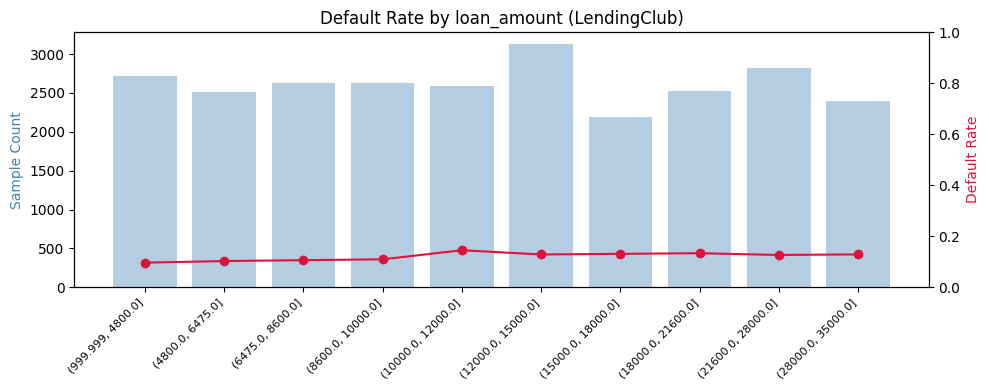

            bucket  count  defaults  default_rate
 (999.999, 4800.0]   2712       262      0.096608
  (4800.0, 6475.0]   2518       259      0.102859
  (6475.0, 8600.0]   2624       279      0.106326
 (8600.0, 10000.0]   2627       288      0.109631
(10000.0, 12000.0]   2594       377      0.145335
(12000.0, 15000.0]   3124       402      0.128681
(15000.0, 18000.0]   2196       288      0.131148
(18000.0, 21600.0]   2529       338      0.133650
(21600.0, 28000.0]   2817       357      0.126731
(28000.0, 35000.0]   2403       310      0.129005

Prosper:


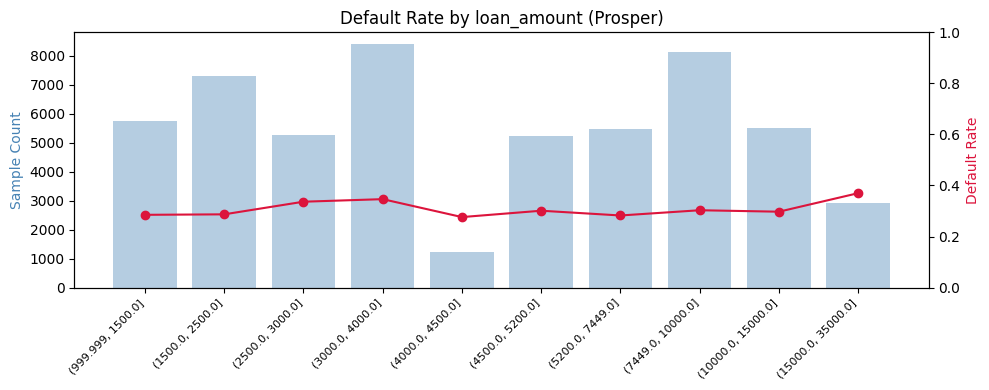

            bucket  count  defaults  default_rate
 (999.999, 1500.0]   5748      1638      0.284969
  (1500.0, 2500.0]   7279      2088      0.286853
  (2500.0, 3000.0]   5245      1764      0.336320
  (3000.0, 4000.0]   8381      2903      0.346379
  (4000.0, 4500.0]   1235       341      0.276113
  (4500.0, 5200.0]   5212      1569      0.301036
  (5200.0, 7449.0]   5450      1539      0.282385
 (7449.0, 10000.0]   8118      2459      0.302907
(10000.0, 15000.0]   5488      1631      0.297194
(15000.0, 35000.0]   2915      1078      0.369811

Feature: DTI

HMEQ:


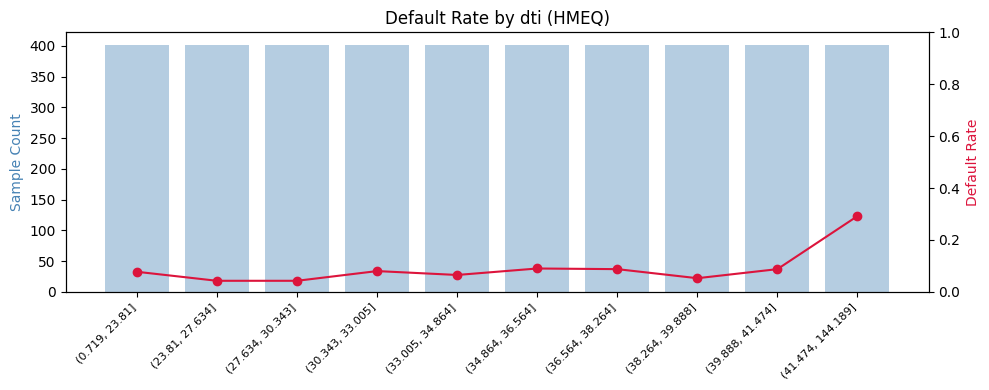

           bucket  count  defaults  default_rate
   (0.719, 23.81]    402        31      0.077114
  (23.81, 27.634]    401        17      0.042394
 (27.634, 30.343]    401        17      0.042394
 (30.343, 33.005]    401        32      0.079800
 (33.005, 34.864]    401        26      0.064838
 (34.864, 36.564]    401        36      0.089776
 (36.564, 38.264]    401        35      0.087282
 (38.264, 39.888]    401        21      0.052369
 (39.888, 41.474]    401        35      0.087282
(41.474, 144.189]    401       117      0.291771

LendingClub:


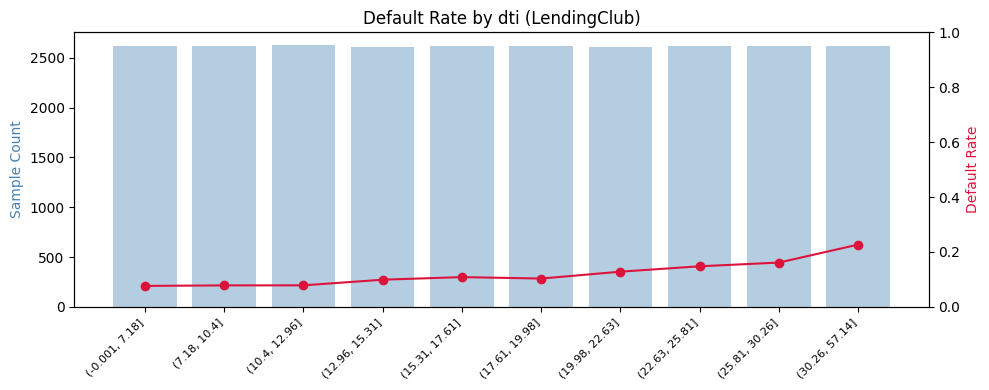

        bucket  count  defaults  default_rate
(-0.001, 7.18]   2616       200      0.076453
  (7.18, 10.4]   2616       205      0.078364
 (10.4, 12.96]   2623       206      0.078536
(12.96, 15.31]   2604       258      0.099078
(15.31, 17.61]   2617       284      0.108521
(17.61, 19.98]   2615       270      0.103250
(19.98, 22.63]   2611       335      0.128303
(22.63, 25.81]   2616       387      0.147936
(25.81, 30.26]   2613       422      0.161500
(30.26, 57.14]   2613       593      0.226942

Prosper:


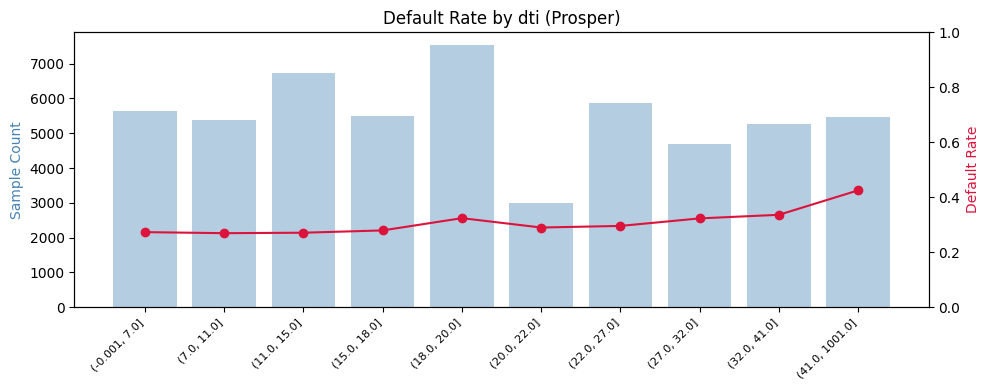

        bucket  count  defaults  default_rate
 (-0.001, 7.0]   5632      1539      0.273260
   (7.0, 11.0]   5385      1451      0.269452
  (11.0, 15.0]   6746      1829      0.271124
  (15.0, 18.0]   5503      1538      0.279484
  (18.0, 20.0]   7525      2439      0.324120
  (20.0, 22.0]   2993       868      0.290010
  (22.0, 27.0]   5871      1737      0.295861
  (27.0, 32.0]   4693      1517      0.323247
  (32.0, 41.0]   5263      1770      0.336310
(41.0, 1001.0]   5460      2322      0.425275

Feature: DELINQ_ANNUAL

HMEQ:


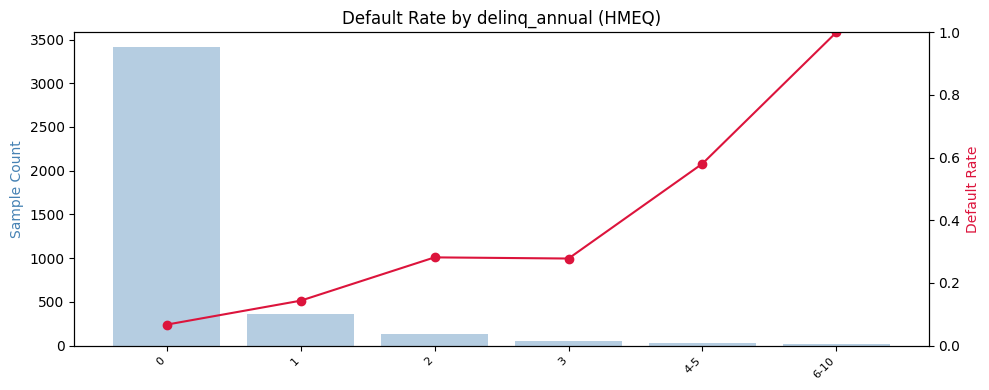

bucket  count  defaults  default_rate
     0   3412       228      0.066823
     1    363        52      0.143251
     2    135        38      0.281481
     3     54        15      0.277778
   4-5     31        18      0.580645
  6-10     16        16      1.000000

LendingClub:


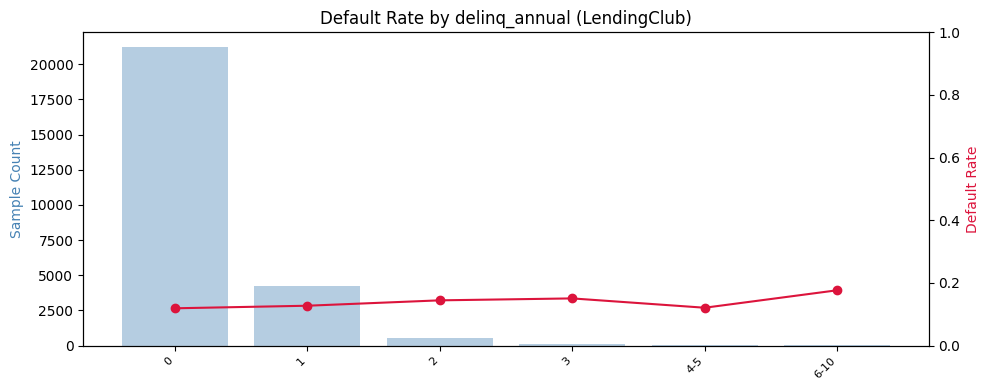

bucket  count  defaults  default_rate
     0  21208      2521      0.118870
     1   4242       539      0.127063
     2    506        73      0.144269
     3    113        17      0.150442
   4-5     58         7      0.120690
  6-10     17         3      0.176471

Prosper:


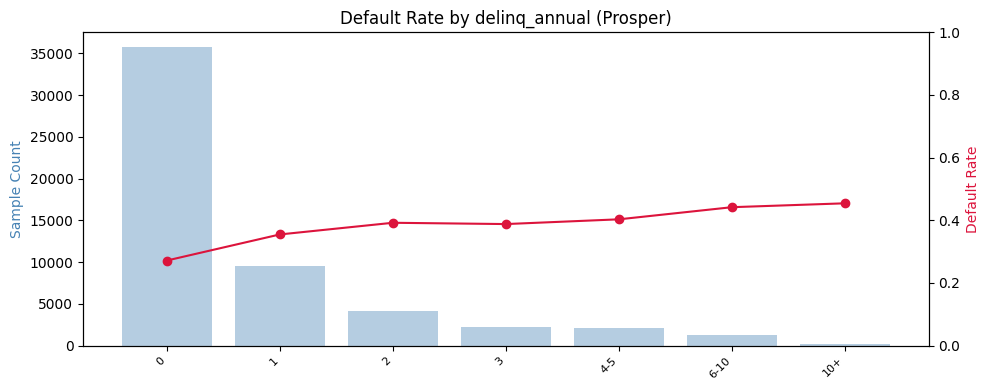

bucket  count  defaults  default_rate
     0  35721      9694      0.271381
     1   9541      3384      0.354680
     2   4118      1614      0.391938
     3   2184       847      0.387821
   4-5   2082       839      0.402978
  6-10   1218       538      0.441708
   10+    207        94      0.454106

Feature: DEROGATORY_MARKS

HMEQ:


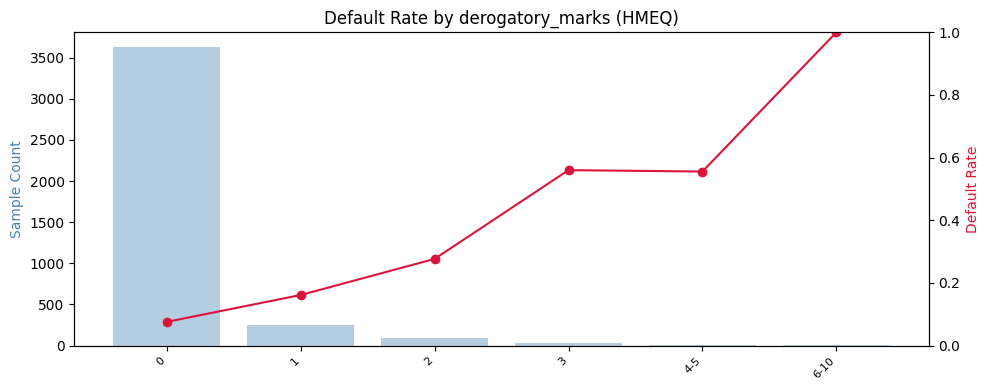

bucket  count  defaults  default_rate
     0   3627       274      0.075545
     1    248        40      0.161290
     2     94        26      0.276596
     3     25        14      0.560000
   4-5      9         5      0.555556
  6-10      8         8      1.000000

LendingClub:


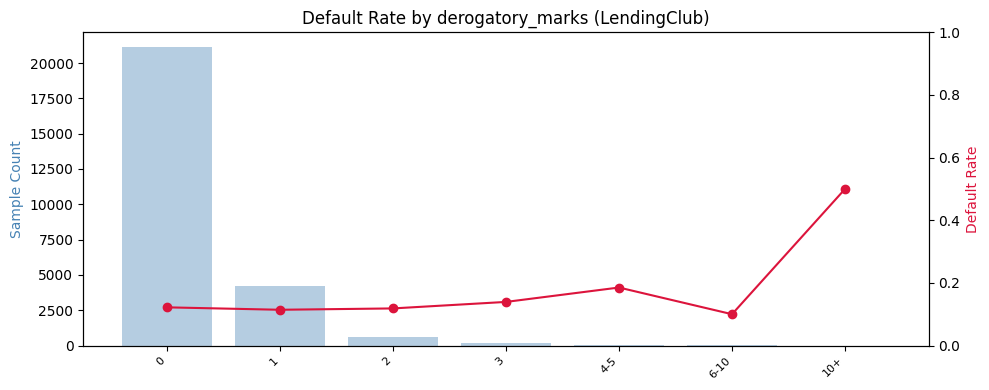

bucket  count  defaults  default_rate
     0  21116      2575      0.121945
     1   4230       483      0.114184
     2    574        68      0.118467
     3    158        22      0.139241
   4-5     54        10      0.185185
  6-10     10         1      0.100000
   10+      2         1      0.500000

Prosper:


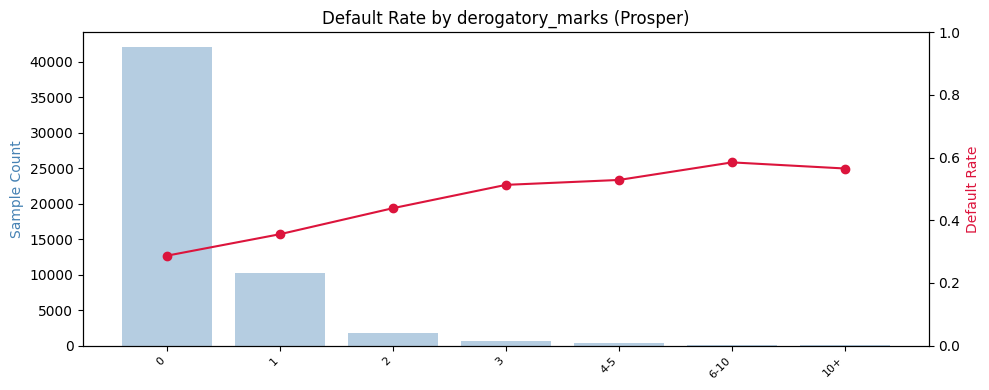

bucket  count  defaults  default_rate
     0  42031     12055      0.286812
     1  10284      3655      0.355406
     2   1724       756      0.438515
     3    577       296      0.512998
   4-5    314       166      0.528662
  6-10    118        69      0.584746
   10+     23        13      0.565217

Feature: INQUIRIES

HMEQ:


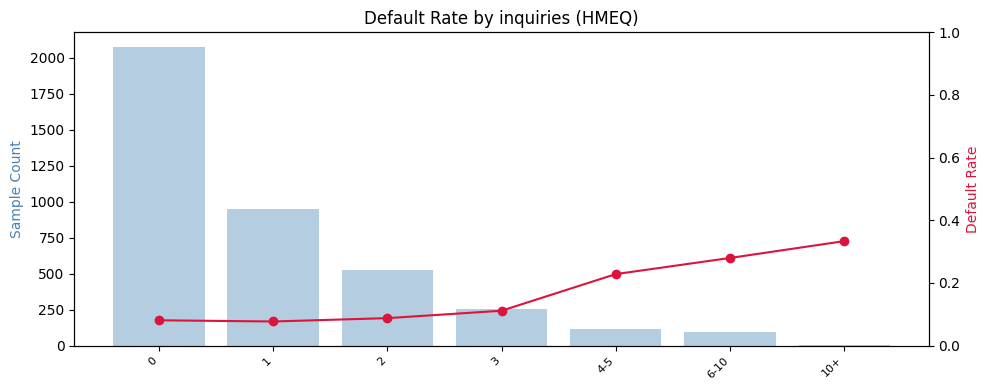

bucket  count  defaults  default_rate
     0   2072       167      0.080598
     1    951        73      0.076761
     2    526        46      0.087452
     3    252        28      0.111111
   4-5    114        26      0.228070
  6-10     93        26      0.279570
   10+      3         1      0.333333

LendingClub:


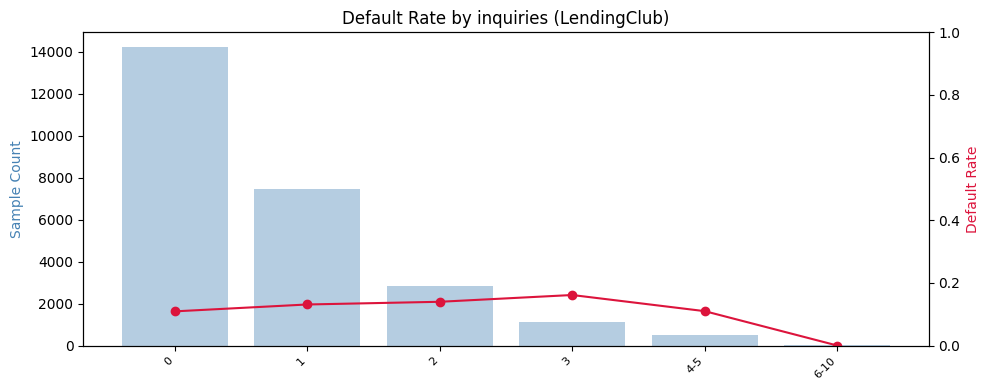

bucket  count  defaults  default_rate
     0  14222      1551      0.109056
     1   7478       980      0.131051
     2   2828       395      0.139675
     3   1116       180      0.161290
   4-5    492        54      0.109756
  6-10      8         0      0.000000

Prosper:


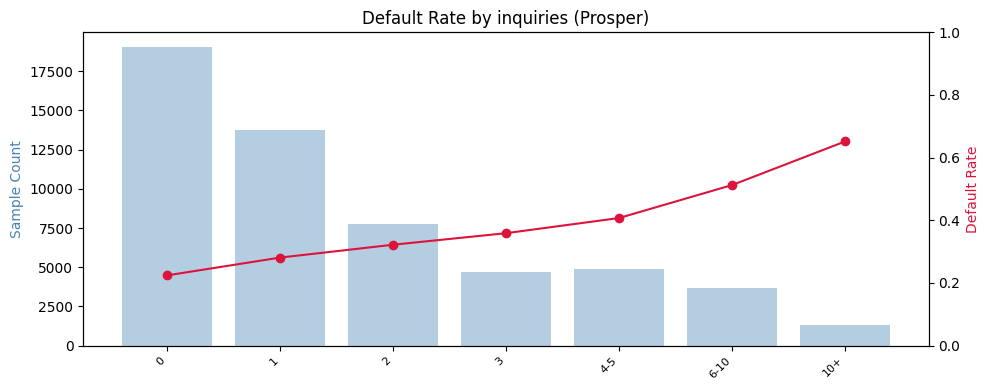

bucket  count  defaults  default_rate
     0  19035      4261      0.223851
     1  13748      3859      0.280695
     2   7757      2496      0.321774
     3   4684      1680      0.358668
   4-5   4864      1980      0.407072
  6-10   3683      1887      0.512354
   10+   1300       847      0.651538


In [ ]:
def default_rate_by_bucket(df, feature, dataset_name,
                            target='is_default', n_bins=10, method='quantile'):
    temp = df[[feature, target]].dropna()

    skewed_cols = ['derogatory_marks', 'delinq_annual', 'inquiries']

    if feature in skewed_cols:
        max_val = temp[feature].max()
        upper = max(11, max_val + 1)
        temp['bucket'] = pd.cut(
            temp[feature],
            bins=[-1, 0, 1, 2, 3, 5, 10, upper],
            labels=['0', '1', '2', '3', '4-5', '6-10', '10+']
        )
    elif method == 'quantile':
        temp['bucket'] = pd.qcut(temp[feature], q=n_bins, duplicates='drop')
    else:
        temp['bucket'] = pd.cut(temp[feature], bins=n_bins, duplicates='drop')

    summary = temp.groupby('bucket', observed=True).agg(
        count=(target, 'count'),
        defaults=(target, 'sum')
    )
    summary['default_rate'] = summary['defaults'] / summary['count']
    summary = summary.reset_index()

    # visualization
    fig, ax1 = plt.subplots(figsize=(10, 4))
    ax2 = ax1.twinx()

    ax1.bar(range(len(summary)), summary['count'], color='steelblue', alpha=0.4)
    ax2.plot(range(len(summary)), summary['default_rate'], color='crimson', marker='o')

    ax1.set_xticks(range(len(summary)))
    ax1.set_xticklabels([str(b) for b in summary['bucket']], rotation=45, ha='right', fontsize=8)
    ax1.set_ylabel('Sample Count', color='steelblue')
    ax2.set_ylabel('Default Rate', color='crimson')
    ax2.set_ylim(0, 1)

    plt.title(f'Default Rate by {feature} ({dataset_name})')
    fig.tight_layout()
    plt.show()

    return summary

# load all 3 datasets
df_hmeq = pd.read_csv('/content/drive/MyDrive/sc3021/cleaned_datasets/hmeq_cleaned.csv')
df_lc = pd.read_csv('/content/drive/MyDrive/sc3021/cleaned_datasets/lendingclub_cleaned.csv')
df_prosper = pd.read_csv('/content/drive/MyDrive/sc3021/cleaned_datasets/prosper_cleaned.csv')

# run bucketing for all 3 datasets
datasets = [
    (df_hmeq,   'HMEQ'),
    (df_lc,     'LendingClub'),
    (df_prosper,'Prosper')
]

features = ['loan_amount', 'dti', 'delinq_annual', 'derogatory_marks', 'inquiries']

for feat in features:
    print(f"\nFeature: {feat.upper()}")

    for df, name in datasets:
        print(f"\n{name}:")
        summary = default_rate_by_bucket(df, feat, dataset_name=name)
        print(summary.to_string(index=False))

# Predictive Analylsis - Random Forest Classification

---



**Goal.** The goal is to identify which of the five cross-comparable borrower
characteristics: loan amount, debt-to-income ratio, annual delinquency rate,
derogatory marks, and credit inquiries, best predict default in each lending context and whether their importance differes across secured lending (HMEQ) and unsecured P2P lending (LendingClub and Prosper).

**Methods / measures.** We used binary classification, predicting whether a loan results in default (1) or not (0) based on five cross-comparable features. A Random Forest classifier is trained seperately on each dataset with the same five features, allowing feature importances to be extracted and compared across lending contexts.

We chose Random Forest over a single decision tree as it can aggregate predictions across 100 decision trees, reducing overfitting and producing reliable importance estimates.
The class_weight='balanced' parameter accounts for approximately 80/20 class imbalance present in the 3 datasets.
Model performance is evaluated using precision, recall, and F1-score from the
classification report, assessing the model's ability to correctly identify both
defaulters and non-defaulters.


Dataset: HMEQ
Usable rows: 4,011 | Defaults: 367 (9.1%)

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.99      0.96       730
           1       0.83      0.34      0.49        73

    accuracy                           0.93       803
   macro avg       0.89      0.67      0.73       803
weighted avg       0.93      0.93      0.92       803


Dataset: LendingClub
Usable rows: 26,144 | Defaults: 3,160 (12.1%)

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.97      0.92      4597
           1       0.19      0.06      0.09       632

    accuracy                           0.86      5229
   macro avg       0.53      0.51      0.50      5229
weighted avg       0.80      0.86      0.82      5229


Dataset: Prosper
Usable rows: 55,071 | Defaults: 17,010 (30.9%)

Classification Report:
              precision    recall  f1-score   support

           0       0.72      

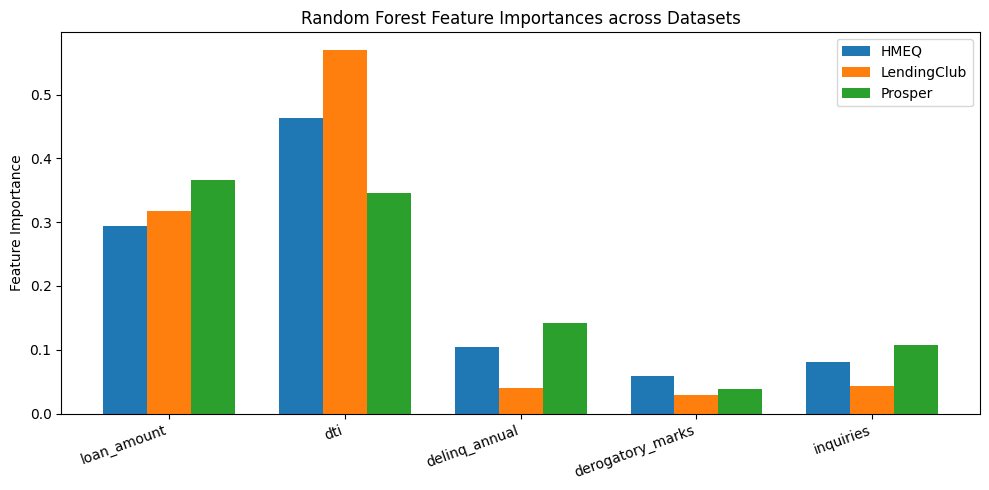

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# load cleaned datasets
df_hmeq    = pd.read_csv('/content/drive/MyDrive/sc3021/cleaned_datasets/hmeq_cleaned.csv')
df_lc      = pd.read_csv('/content/drive/MyDrive/sc3021/cleaned_datasets/lendingclub_cleaned.csv')
df_prosper = pd.read_csv('/content/drive/MyDrive/sc3021/cleaned_datasets/prosper_cleaned.csv')

# core features (standardised names)
FEATURES = ['loan_amount', 'dti', 'delinq_annual', 'derogatory_marks', 'inquiries']
TARGET   = 'is_default'

datasets = [
    (df_hmeq,    'HMEQ'),
    (df_lc,      'LendingClub'),
    (df_prosper, 'Prosper')
]

results = {}

for df, name in datasets:
    print(f"\nDataset: {name}")

    # drop rows with nulls in the 5 features or target
    model_df = df[FEATURES + [TARGET]].dropna()
    X = model_df[FEATURES]
    y = model_df[TARGET]

    print(f"Usable rows: {len(model_df):,} | Defaults: {y.sum():,} ({y.mean()*100:.1f}%)")

    # train/test split, stratified to preserve default rate
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y)

    # train Random Forest
    rf = RandomForestClassifier(
        n_estimators=100,
        class_weight='balanced',
        random_state=42
    )
    rf.fit(X_train, y_train)

    # evaluate
    y_pred = rf.predict(X_test)

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # store results
    results[name] = {
        'importances': dict(zip(FEATURES, rf.feature_importances_))
    }

# feature importance comparison chart
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(FEATURES))
width = 0.25

for i, (name, res) in enumerate(results.items()):
    vals = [res['importances'][f] for f in FEATURES]
    ax.bar(x + i * width, vals, width, label=name)

ax.set_xticks(x + width)
ax.set_xticklabels(FEATURES, rotation=20, ha='right')
ax.set_ylabel('Feature Importance')
ax.set_title('Random Forest Feature Importances across Datasets')
ax.legend()
plt.tight_layout()
plt.show()

**Interpretation.** The feature importance chart shows that DTI and loan amount
clearly dominate across all three datasets, confirming them as the strongest
predictors of default regardless of lending context. Delinquency rate, derogatory
marks, and inquiries contribute less overall, though their relative importance
varies noticeably across datasets. This is explored further in the cross-dataset
comparison below.

The classification reports reveal a consistent pattern: the model identifies
non-defaulters well but struggles to catch actual defaulters. In HMEQ, when the
model predicts a default it is correct 83% of the time (precision), but only
catches 34% of actual defaulters (recall). LendingClub shows the weakest default
detection with precision of 0.19 and recall of just 0.06, meaning fewer than 1
in 10 actual defaulters are identified. Prosper performs best for default
detection with precision 0.38 and recall 0.33, likely because its higher default
rate of 30.9% provides more positive examples for the model to learn from
compared to HMEQ (9.1%) and LendingClub (12.1%).

**Limitations.** The consistently low recall for the default class across all
three datasets indicates that the five features alone are insufficient to reliably
identify defaulters, particularly in LendingClub where recall is only 0.06. The
high class imbalance, especially in HMEQ at 9.1% default rate, limits the
model's ability to learn default patterns even with balanced class weights.
Feature importances reflect predictive contribution within each dataset
independently and should not be interpreted as causal relationships.

# Cross dataset comparison (Addresses primary research question)

**Goal.** The goal is to directly answer the primary research question: Do borrower financial characteristics that predict default risk differ between secured lending (HMEQ) and unsecured peer-to-peer lending (LendingClub, Prosper)? By comparing feature importance rankings across all three datasets, this analysis identifies which risk factors are universal across lending contexts and which are context-specific, informing whether lenders can apply common risk assessment frameworks or require context-tailored approaches.

**Methods / measures.** Feature importance scores from the Random Forest models trained on the five universal characteristics are compared across HMEQ, LendingClub, and Prosper. Variance in importance scores across datasets is calculated for each feature, with low variance indicating universal predictors (consistent importance across contexts) and high variance indicating context-specific predictors (importance varies by lending type). Features are ranked by importance within each dataset to assess whether the same characteristics emerge as top predictors across all contexts. The analysis distinguishes between secured lending (HMEQ, where property serves as collateral) and unsecured P2P lending (LendingClub and Prosper, where loans are backed only by borrower creditworthiness). Average variance across all five features quantifies overall consistency, with thresholds of less than 0.01 indicating high consistency, 0.01-0.03 indicating moderate consistency, and greater than 0.03 indicating substantial context-specific differences.

In [ ]:
print("Cross dataset comparison")

# feature importance comparison table with variance
print(f"\n{'Feature':<25} {'HMEQ':>12} {'LendingClub':>15} {'Prosper':>12} {'Variance':>10}")

importance_variance = {}

for feat in FEATURES:
    h_imp  = results['HMEQ']['importances'][feat]
    lc_imp = results['LendingClub']['importances'][feat]
    p_imp  = results['Prosper']['importances'][feat]

    # calculate variance across the three datasets
    variance = np.var([h_imp, lc_imp, p_imp])

    print(f"{feat:<25} {h_imp:>12.3f} {lc_imp:>15.3f} {p_imp:>12.3f} {variance:>10.4f}")
    importance_variance[feat] = variance

print("\nUniversal vs Context-specific features")

# sort features by variance (low = universal, high = context-specific)
sorted_features = sorted(importance_variance.items(), key=lambda x: x[1])

print("\nMost universal features (low variance, consistent across contexts):")
for feat, var in sorted_features[:2]:
    print(f"  {feat} (variance: {var:.4f})")
    print(f"  Consistent importance across all lending contexts")

print("\nMost context-specific features (high variance, differs by context):")
for feat, var in sorted_features[-2:]:
    print(f"  {feat} (variance: {var:.4f})")
    print(f"  Importance varies significantly across lending contexts")

# overall interpretation
avg_variance = np.mean(list(importance_variance.values()))
print(f"\nAverage importance variance across features: {avg_variance:.4f}")

if avg_variance < 0.01:
    print("\nRisk factors are highly consistent across lending contexts")
    print("Same borrower characteristics predict default similarly in all contexts")
elif avg_variance < 0.03:
    print("\nRisk factors show moderate consistency across lending contexts")
    print("Core patterns are similar, but some context-specific differences exist")
else:
    print("\nRisk factors differ substantially across lending contexts")
    print("Secured vs unsecured lending have fundamentally different risk dynamics")

Cross dataset comparison

Feature                           HMEQ     LendingClub      Prosper   Variance
loan_amount                      0.293           0.317        0.366     0.0009
dti                              0.463           0.569        0.346     0.0083
delinq_annual                    0.104           0.041        0.143     0.0018
derogatory_marks                 0.058           0.029        0.038     0.0001
inquiries                        0.081           0.044        0.107     0.0007

Universal vs Context-specific features

Most universal features (low variance, consistent across contexts):
  derogatory_marks (variance: 0.0001)
  Consistent importance across all lending contexts
  inquiries (variance: 0.0007)
  Consistent importance across all lending contexts

Most context-specific features (high variance, differs by context):
  delinq_annual (variance: 0.0018)
  Importance varies significantly across lending contexts
  dti (variance: 0.0083)
  Importance varies significant

**Interpretation.** The cross-dataset variance analysis reveals that risk factors
are highly consistent across lending contexts, with an average importance variance
of 0.0024, is well below the 0.01 threshold for high consistency. This means the
same five borrower characteristics predict default in a broadly similar manner
across secured home equity lending and unsecured P2P lending.

DTI is the strongest predictor across all three datasets with importance scores
of 0.463 (HMEQ), 0.569 (LendingClub), and 0.346 (Prosper), though it also shows
the highest variance at 0.0083, making it the most context-dependent feature.
Loan amount ranks second in HMEQ (0.293) and LendingClub (0.317) but takes the
top position in Prosper (0.366), with a low variance of 0.0009 indicating
consistent overall importance despite the ranking shift. Together, DTI and loan
amount confirm financial capacity and exposure as the two dominant universal
risk signals.

Derogatory marks and inquiries emerge as the most universal features with
variances of 0.0001 and 0.0007 respectively, maintaining nearly identical
importance across all three lending contexts. Delinq_annual shows the second
highest variance at 0.0018, with notably lower importance in LendingClub (0.041)
compared to HMEQ (0.104) and Prosper (0.143), suggesting that past payment
behaviour is a more meaningful risk signal in secured and marketplace lending
than in peer-to-peer lending.

**Limitations.** Variance as a consistency metric assumes equal weighting across
datasets, though the three datasets differ substantially in size and default rate,
which may influence the reliability of importance estimates. Feature importances
reflect predictive contribution within each dataset independently and should not
be interpreted as causal relationships between borrower characteristics and
default outcomes.

# Lending Club vs Prosper (Addresses secondary research question)

**Goal.** The goal is to directly answer the secondary research question: Are default-predictive patterns among peer-to-peer borrowers consistent across lending platforms (LendingClub vs Prosper), or are they platform-specific? This analysis determines whether the same risk assessment frameworks apply to both P2P platforms or whether each platform's unique borrower pool, underwriting criteria, and operational model require tailored approaches. The findings inform whether risk models trained on one P2P platform can generalize to other P2P environments or whether platform-specific models are necessary.

**Methods / measures.** Feature importance scores from Random Forest models trained on the five universal characteristics are compared between LendingClub and Prosper exclusively, isolating the P2P lending context. The average absolute difference in importance scores across the five features quantifies consistency, with thresholds of less than 0.05 indicating high consistency, 0.05-0.10 indicating moderate consistency, and greater than 0.10 indicating platform-specific patterns. Feature rankings are compared by sorting features in descending order of importance for each platform, with particular attention to the top three most important predictors to assess whether platforms agree on which characteristics matter most. The maximum difference identifies which feature shows the most platform-dependent behavior. Visual side-by-side bar charts illustrate importance differences feature-by-feature, allowing direct comparison of how each borrower characteristic contributes to default prediction on each platform.

Secondary RQ: LendingClub vs Prosper

Research Question: Are P2P default patterns consistent across
platforms, or are they platform-specific?

Feature Importance Comparison (P2P Platforms Only):
Feature                       LendingClub         Prosper      Difference
loan_amount                         0.317           0.366          -0.049
dti                                 0.569           0.346          +0.223
delinq_annual                       0.041           0.143          -0.102
derogatory_marks                    0.029           0.038          -0.009
inquiries                           0.044           0.107          -0.063


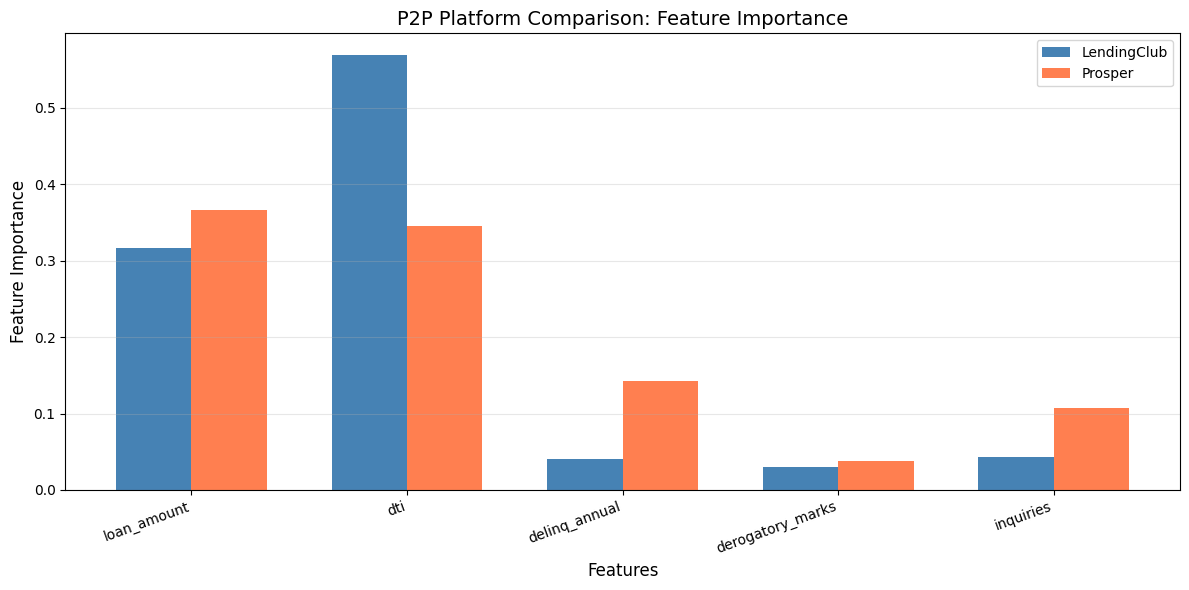


Consistency Assessment
Average absolute difference: 0.089
Maximum difference: 0.223 (feature: dti)

Moderately consistent: Some platform differences exist
Core risk factors align, but platform-specific calibration recommended

Feature Ranking Comparison

Rank   LendingClub               Prosper                  
1      dti                       loan_amount              
2      loan_amount               dti                      
3      inquiries                 delinq_annual            
4      delinq_annual             inquiries                
5      derogatory_marks          derogatory_marks         

Top 3 features overlap: 2/3 features
LendingClub top 3: dti, loan_amount, inquiries
Prosper top 3:     loan_amount, dti, delinq_annual

Platforms mostly agree on which features matter most


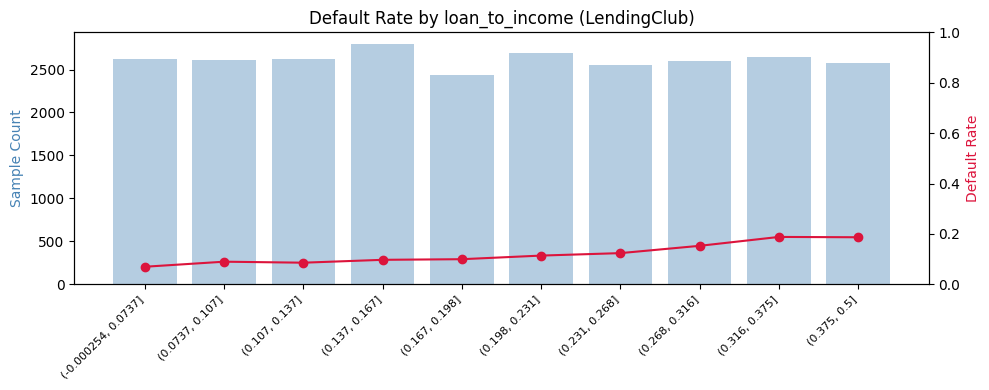

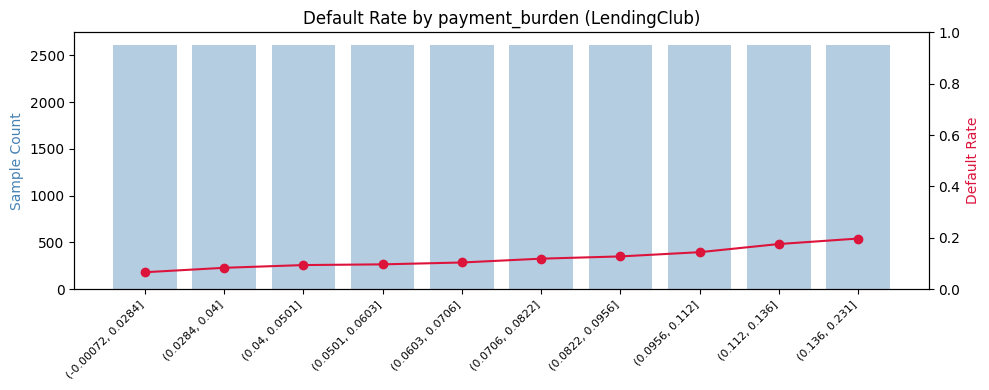

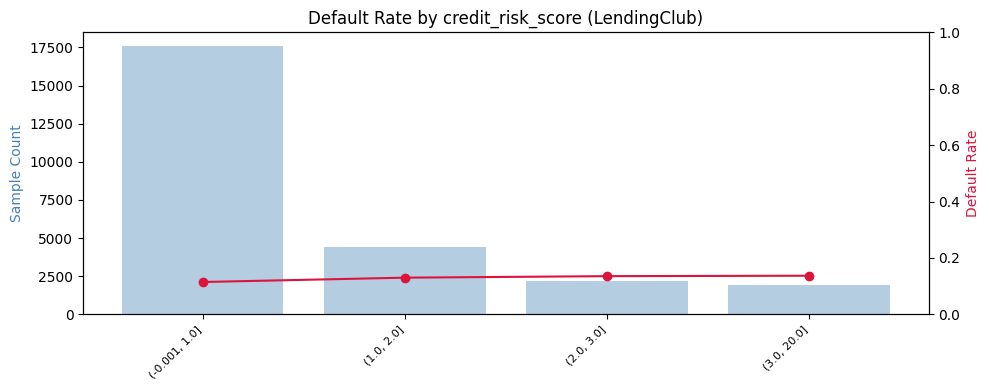

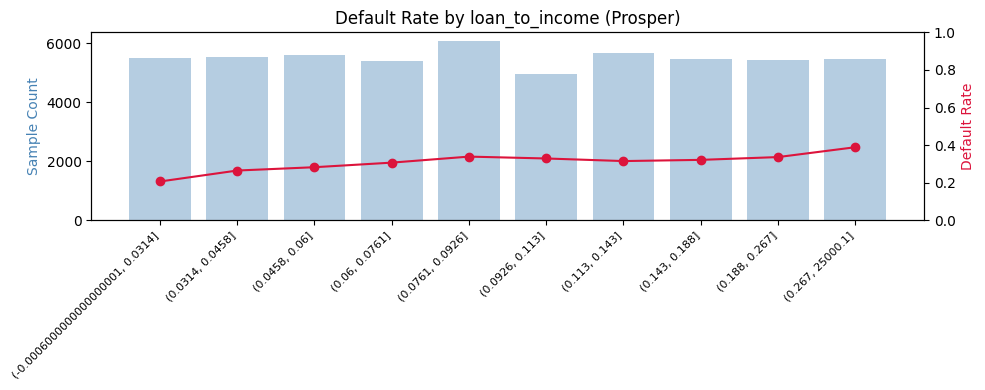

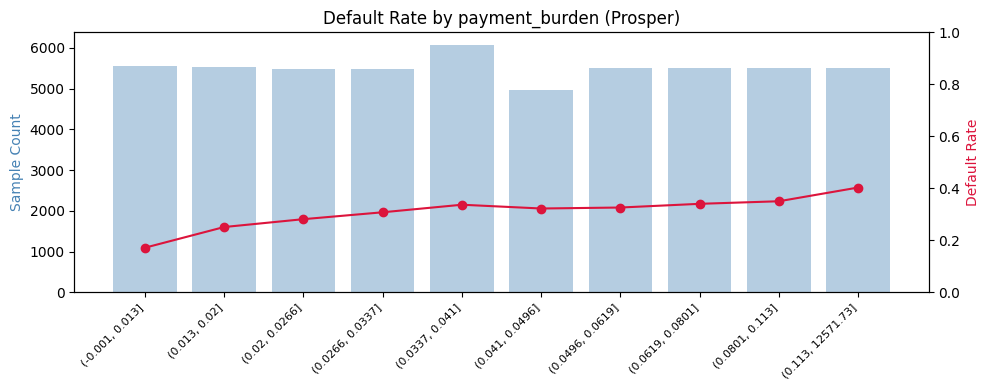

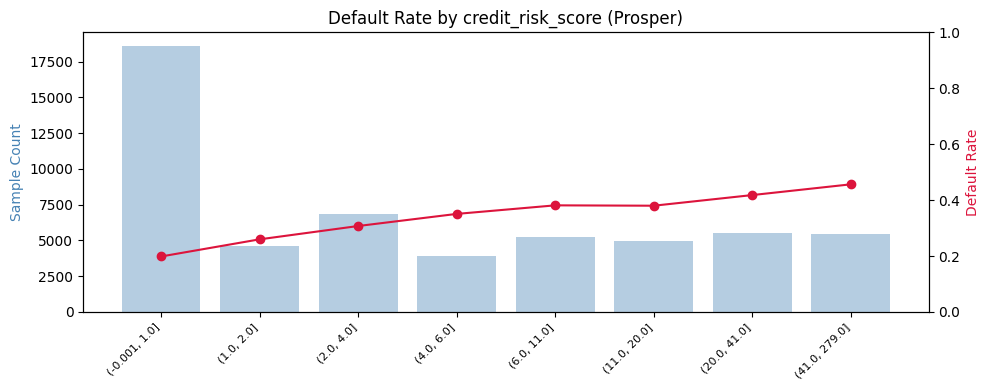

In [ ]:
print("Secondary RQ: LendingClub vs Prosper")
print("\nResearch Question: Are P2P default patterns consistent across")
print("platforms, or are they platform-specific?\n")

# extract feature importances for P2P platforms only
lc_importances = results['LendingClub']['importances']
prosper_importances = results['Prosper']['importances']

# feature by feature comparison
print("Feature Importance Comparison (P2P Platforms Only):")
print(f"{'Feature':<25} {'LendingClub':>15} {'Prosper':>15} {'Difference':>15}")

for feat in FEATURES:
    lc_imp = lc_importances[feat]
    p_imp  = prosper_importances[feat]
    diff   = lc_imp - p_imp
    print(f"{feat:<25} {lc_imp:>15.3f} {p_imp:>15.3f} {diff:>+15.3f}")

# visualization: side by side comparison
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(FEATURES))
width = 0.35

lc_vals = [lc_importances[f] for f in FEATURES]
p_vals  = [prosper_importances[f] for f in FEATURES]

ax.bar(x - width/2, lc_vals, width, label='LendingClub', color='steelblue')
ax.bar(x + width/2, p_vals, width, label='Prosper', color='coral')

ax.set_xlabel('Features', fontsize=12)
ax.set_ylabel('Feature Importance', fontsize=12)
ax.set_title('P2P Platform Comparison: Feature Importance', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(FEATURES, rotation=20, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# statistical comparison
print("\nConsistency Assessment")

# calculate average absolute difference
abs_diffs = [abs(lc_importances[f] - prosper_importances[f]) for f in FEATURES]
avg_diff = np.mean(abs_diffs)
max_diff = max(abs_diffs)
max_diff_feature = FEATURES[abs_diffs.index(max_diff)]

print(f"Average absolute difference: {avg_diff:.3f}")
print(f"Maximum difference: {max_diff:.3f} (feature: {max_diff_feature})")

# consistency interpretation
if avg_diff < 0.05:
    print("\nConsistent: P2P patterns are similar across platforms")
    print("Risk models should generalize well between LendingClub and Prosper")
elif avg_diff < 0.10:
    print("\nModerately consistent: Some platform differences exist")
    print("Core risk factors align, but platform-specific calibration recommended")
else:
    print("\nPlatform-specific: Patterns differ substantially")
    print("Each platform requires distinct risk assessment models")

# feature ranking comparison
print("\nFeature Ranking Comparison")

lc_ranking = sorted(FEATURES, key=lambda f: lc_importances[f], reverse=True)
p_ranking  = sorted(FEATURES, key=lambda f: prosper_importances[f], reverse=True)

print(f"\n{'Rank':<6} {'LendingClub':<25} {'Prosper':<25}")

for i in range(len(FEATURES)):
    print(f"{i+1:<6} {lc_ranking[i]:<25} {p_ranking[i]:<25}")

# check top 3 agreement
lc_top3 = set(lc_ranking[:3])
p_top3  = set(p_ranking[:3])
overlap = lc_top3.intersection(p_top3)

print(f"\nTop 3 features overlap: {len(overlap)}/3 features")
print(f"LendingClub top 3: {', '.join(lc_ranking[:3])}")
print(f"Prosper top 3:     {', '.join(p_ranking[:3])}")

if len(overlap) == 3:
    print("\nBoth platforms fully agree on top 3 most important features")
elif len(overlap) >= 2:
    print("\nPlatforms mostly agree on which features matter most")
else:
    print("\nPlatforms disagree on which features are most important")

# supplementary analysis
# map LC enriched columns
df_lc['loan_to_income']    = df_lc['LOAN_TO_INCOME']
df_lc['payment_burden']    = df_lc['INSTALLMENT_TO_INCOME']
df_lc['credit_risk_score'] = df_lc['CREDIT_RISK_SCORE']

# map Prosper enriched columns
df_prosper['loan_to_income'] = df_prosper['loan_to_income_ratio']
df_prosper['payment_burden'] = df_prosper['payment_burden_ratio']
# credit_risk_score already exists in Prosper

ENRICHED = ['loan_to_income', 'payment_burden', 'credit_risk_score']

# use dataset_df instead of df to avoid overwriting global df
for dataset_df, name in [(df_lc, 'LendingClub'), (df_prosper, 'Prosper')]:
    for feat in ENRICHED:
        summary = default_rate_by_bucket(dataset_df, feat, dataset_name=name)

**Interpretation.** The average absolute difference in feature importance between LendingClub and Prosper is 0.089, indicating moderately consistent default-predictive patterns across platforms. Core risk factors align, but platform-specific differences exist that warrant calibration when applying models across platforms. DTI shows the largest platform difference at 0.223, serving as the strongest predictor on LendingClub with importance of 0.569 but ranking second on Prosper at 0.346. This reversal is mirrored in loan amount, which ranks second on LendingClub at 0.317 but takes the top position on Prosper at 0.366. This suggests that LendingClub's risk assessment framework emphasizes borrower debt capacity more heavily, while Prosper places greater weight on absolute financial exposure. Delinquency rate exhibits notable platform variation as well, with importance of 0.041 on LendingClub versus 0.143 on Prosper, ranking fourth and third respectively. This threefold difference indicates that past payment behavior plays a substantially more prominent role in Prosper's default risk assessment than in LendingClub's. The feature ranking comparison reveals 2 out of 3 agreement in top predictors (both platforms rank DTI and loan amount as their two most important features, though in reversed order). The third position diverges, with LendingClub prioritizing inquiries at 0.044 and Prosper prioritizing delinquencies at 0.143. Derogatory marks shows the most consistent cross-platform behavior, with nearly identical importance of 0.029 on LendingClub and 0.038 on Prosper, ranking last on both platforms. These patterns indicate that while general P2P risk principles transfer across platforms (DTI and loan amount universally dominate prediction), the relative weighting differs enough to recommend platform-specific calibration for optimal model performance.

**Limitations.** LendingClub and Prosper data may represent different time periods, economic conditions, or regulatory environments that could influence apparent platform differences beyond inherent borrower pool or operational distinctions. The analysis uses data from 2015 for LendingClub, so temporal effects or changes in platform policies since that time may confound platform-specific patterns. The five universal features may not capture platform-specific factors such as proprietary credit grading systems (LendingClub's A-G grades vs Prosper's AA-HR ratings), auction-based versus instant funding mechanisms, or borrower-investor matching approaches that differentiate the platforms' operational models. Observed differences reflect predictive contribution within the Random Forest models but do not establish whether platforms actively apply different underwriting standards or simply attract different borrower populations through marketing strategies, interest rate pricing, or user experience design differences.

# Presentation of main results (Share)

## Stakeholders
The results are presented to **credit risk officers and underwriting teams
at consumer lending institutions**, including both traditional secured
lenders and peer-to-peer lending platforms. These stakeholders are responsible
for designing borrower screening frameworks and setting risk thresholds
for loan approval decisions.

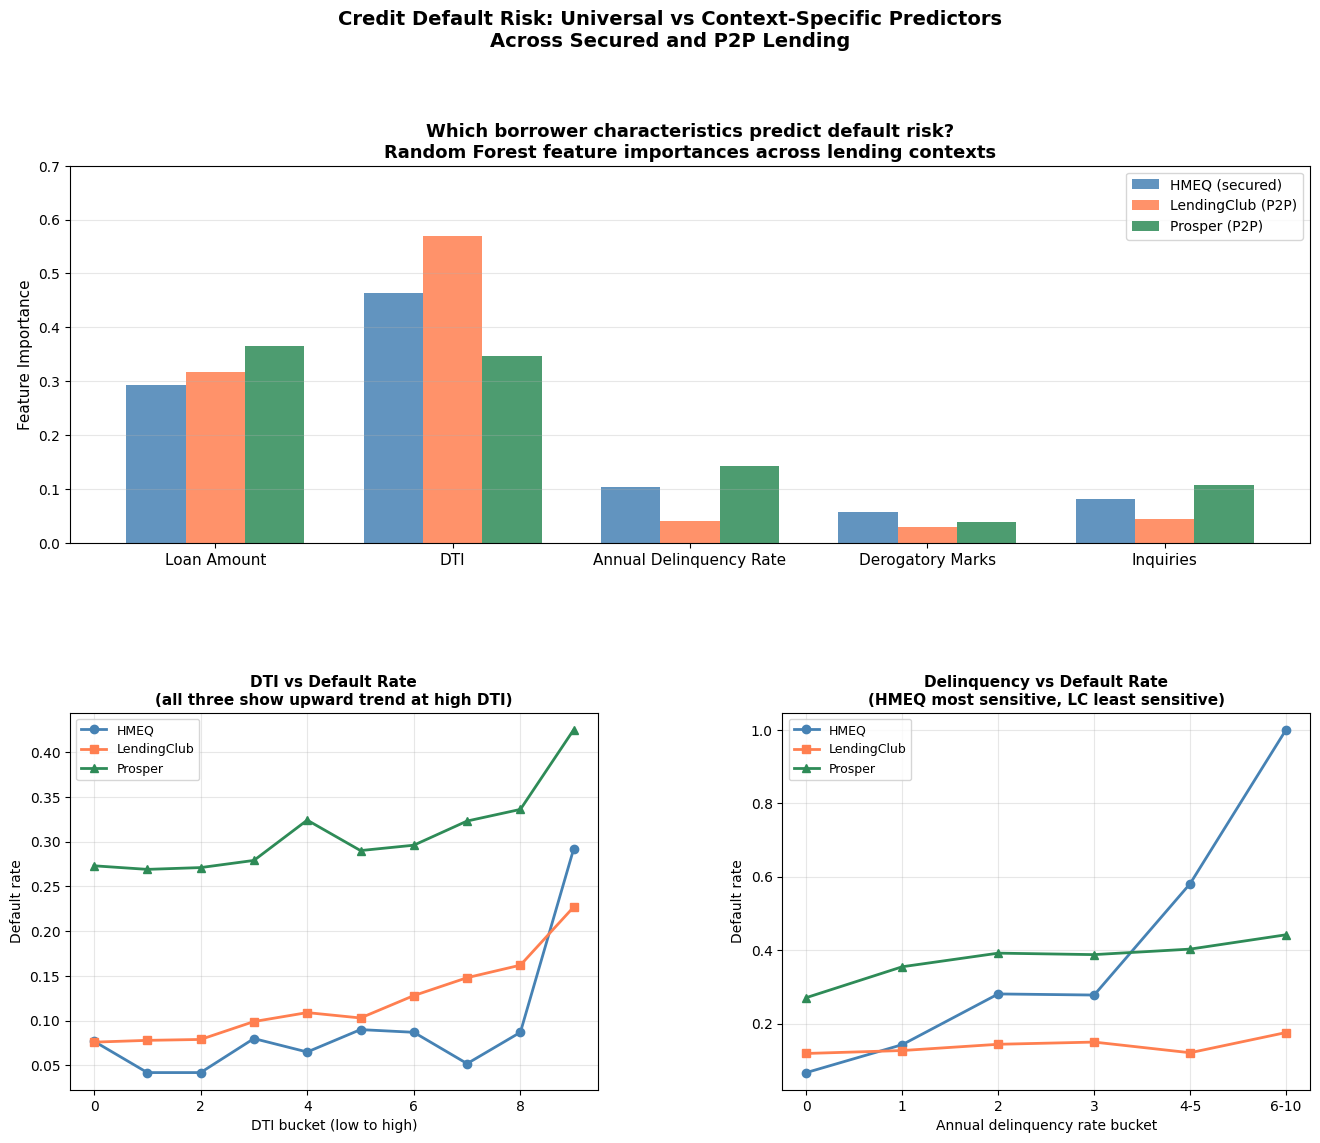

In [ ]:
from matplotlib import gridspec

fig = plt.figure(figsize=(16, 12))
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

# panel 1: Feature importance comparison (full width top)
ax1 = fig.add_subplot(gs[0, :])
x = np.arange(len(FEATURES))
width = 0.25
colors = ['steelblue', 'coral', 'seagreen']
labels = ['HMEQ (secured)', 'LendingClub (P2P)', 'Prosper (P2P)']

hmeq_imp   = [0.293, 0.463, 0.104, 0.058, 0.081]
lc_imp     = [0.317, 0.569, 0.041, 0.029, 0.044]
prosper_imp = [0.366, 0.346, 0.143, 0.038, 0.107]

for i, (vals, color, label) in enumerate(zip([hmeq_imp, lc_imp, prosper_imp], colors, labels)):
    ax1.bar(x + i * width, vals, width, label=label, color=color, alpha=0.85)

ax1.set_xticks(x + width)
feature_labels = ['Loan Amount', 'DTI', 'Annual Delinquency Rate',
                  'Derogatory Marks', 'Inquiries']
ax1.set_xticklabels(feature_labels, fontsize=11)
ax1.set_ylabel('Feature Importance', fontsize=11)
ax1.set_title('Which borrower characteristics predict default risk?\nRandom Forest feature importances across lending contexts',
              fontsize=13, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(axis='y', alpha=0.3)
ax1.set_ylim(0, 0.7)


# panel 2: DTI default rate (all 3 datasets)
ax2 = fig.add_subplot(gs[1, 0])

hmeq_dti    = [0.077, 0.042, 0.042, 0.080, 0.065, 0.090, 0.087, 0.052, 0.087, 0.292]
lc_dti      = [0.076, 0.078, 0.079, 0.099, 0.109, 0.103, 0.128, 0.148, 0.162, 0.227]
prosper_dti = [0.273, 0.269, 0.271, 0.279, 0.324, 0.290, 0.296, 0.323, 0.336, 0.425]

ax2.plot(range(10), hmeq_dti,    marker='o', color='steelblue', label='HMEQ',        linewidth=2)
ax2.plot(range(10), lc_dti,      marker='s', color='coral',     label='LendingClub', linewidth=2)
ax2.plot(range(10), prosper_dti, marker='^', color='seagreen',  label='Prosper',     linewidth=2)
ax2.set_xlabel('DTI bucket (low to high)', fontsize=10)
ax2.set_ylabel('Default rate', fontsize=10)
ax2.set_title('DTI vs Default Rate\n(all three show upward trend at high DTI)',
              fontsize=11, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

# panel 3: Delinquency default rate (all 3 datasets)
ax3 = fig.add_subplot(gs[1, 1])

buckets       = ['0', '1', '2', '3', '4-5', '6-10']
hmeq_delinq   = [0.067, 0.143, 0.281, 0.278, 0.581, 1.000]
lc_delinq     = [0.119, 0.127, 0.144, 0.150, 0.121, 0.176]
prosper_delinq = [0.271, 0.355, 0.392, 0.388, 0.403, 0.442]

ax3.plot(buckets, hmeq_delinq,    marker='o', color='steelblue', label='HMEQ',        linewidth=2)
ax3.plot(buckets, lc_delinq,      marker='s', color='coral',     label='LendingClub', linewidth=2)
ax3.plot(buckets, prosper_delinq, marker='^', color='seagreen',  label='Prosper',     linewidth=2)
ax3.set_xlabel('Annual delinquency rate bucket', fontsize=10)
ax3.set_ylabel('Default rate', fontsize=10)
ax3.set_title('Delinquency vs Default Rate\n(HMEQ most sensitive, LC least sensitive)',
              fontsize=11, fontweight='bold')
ax3.legend(fontsize=9)
ax3.grid(alpha=0.3)

plt.suptitle('Credit Default Risk: Universal vs Context-Specific Predictors\nAcross Secured and P2P Lending',
             fontsize=14, fontweight='bold', y=1.01)
plt.savefig('main_results.png', bbox_inches='tight', dpi=150)
plt.show()

## Narrative

Our analysis of over 500,000 resolved loans across three US lending
contexts - secured home equity (HMEQ), and two peer-to-peer platforms
(LendingClub, Prosper) - produces the following key findings for
credit risk officers:

**Model Performance.** Random Forest classifiers were trained on the five
cross-comparable features across all three lending contexts. HMEQ achieves
stronger default detection performance, as reflected in its higher precision
(0.83) and recall (0.34) for the default class compared to both P2P platforms.
This suggests that default risk in secured home equity lending is more
predictable from these five features alone. The weaker performance on LendingClub
and Prosper, particularly LendingClub's recall of just 0.06, suggests that P2P
default risk is driven by a broader set of factors beyond the five core
attributes, and that platform-specific features may be needed for stronger
predictive performance.

**Finding 1 - DTI and loan amount are universal risk signals.**
DTI is the strongest predictor of default across all three lending
contexts, with importance scores of 0.463 (HMEQ), 0.569 (LendingClub),
and 0.346 (Prosper). Loan amount consistently ranks second across all
three datasets (0.293, 0.317, 0.366). The DTI trend charts confirm
this universality. Default rates rise steadily as DTI increases across
all three platforms, from approximately 7% at low DTI to 29% (HMEQ),
23% (LendingClub), and 43% (Prosper) at extreme DTI levels.
Lenders across all contexts should prioritise DTI and loan amount
as the primary borrower screening criteria.

**Finding 2 - Delinquency history is context-sensitive.**
Annual delinquency rate shows the most striking divergence across
lending contexts. In HMEQ, default rates escalate sharply with
delinquency history - borrowers with 6-10 prior delinquencies
default at 100%, compared to just 6.7% for borrowers with none.
LendingClub shows a near-flat response (11.9% to 17.6%), indicating
delinquency history has limited discriminatory power in unsecured
P2P lending. Prosper sits in between, rising from 27.1% to 44.2%.
This threefold difference in sensitivity confirms that secured
lenders should apply much stricter delinquency thresholds than
P2P platforms. The feature importance scores support this -
delinq_annual ranks third in HMEQ (0.104) and Prosper (0.143)
but fourth in LendingClub (0.041).

**Finding 3 - LendingClub and Prosper show moderate platform
differences.**
While both P2P platforms agree that DTI and loan amount are the
two most important risk factors, they diverge on the third -
LendingClub ranks inquiries third (0.044) while Prosper ranks
annual delinquency rate third (0.143), a threefold difference.
The average absolute difference in feature importance between
the two platforms is 0.089, indicating moderate consistency.
Core risk factors align, but platform-specific calibration is
recommended - risk models trained on LendingClub data should
not be directly applied to Prosper without adjustment,
particularly for delinquency and inquiry thresholds.

# Possible Actions Based on Results (Act)

Based on the findings from this analysis, the following actions
are recommended for credit risk officers and lending institutions:

**1. Adopt DTI and loan amount as universal screening thresholds.**
Since DTI and loan amount are the strongest and most consistent
predictors of default across all three lending contexts, lenders
should establish clear DTI cutoffs in their loan approval frameworks.
The bucket analysis shows that default rates rise sharply beyond
DTI of around 40% in HMEQ and around 30% in LendingClub, suggesting these
as reasonable threshold candidates for initial screening.

**2. Apply context-specific delinquency thresholds.**
Secured lenders should apply strict delinquency screening, even a single prior delinquency doubles the default rate in
HMEQ (6.7% to 14.3%), and borrowers with 4 or more delinquencies
default at over 58%. P2P platforms can afford more lenient
delinquency thresholds since the relationship between delinquency
history and default is much weaker in unsecured lending contexts.
A one-size-fits-all delinquency policy across lending types
would either over-reject creditworthy P2P borrowers or
under-screen high-risk secured borrowers.

**3. Do not apply P2P risk models across platforms without
recalibration.**
LendingClub and Prosper show moderate differences in feature
importance patterns, with delinquency rate being three times
more predictive on Prosper than LendingClub. Risk models
trained on one platform's data should be recalibrated before
deployment on another platform, particularly for delinquency
and inquiry thresholds.

**4. Invest in additional data collection for P2P lending.**
The consistently low recall for the default class in LendingClub (0.06) and
Prosper (0.33) suggests that the five core features alone are insufficient for
reliable default detection in P2P contexts. P2P platforms should consider
incorporating additional borrower signals, such as employment stability, loan
purpose, and credit utilisation, to improve risk model performance.


# Final Reflection

## Considerations on Data Ethics

The use of borrower financial characteristics to predict default
risk raises several ethical considerations that lenders and
policymakers should be aware of.

First, the features used in this analysis - particularly DTI,
loan amount, and delinquency history - may correlate with
socioeconomic status and indirectly with protected characteristics
such as race, ethnicity, or gender. Historically marginalised
groups may have higher DTI ratios or delinquency counts due to
systemic inequalities rather than individual financial behaviour,
meaning a model trained on these features could perpetuate or
amplify existing discrimination in lending decisions.

Second, Prosper's dataset covers a significant proportion of
pre-2009 loans originated before modern fair lending regulations
were fully established. The higher default rate in Prosper (30.5%)
compared to HMEQ (19.9%) and LendingClub (19.8%) may partly
reflect this historical context rather than genuine differences
in borrower risk profiles, and conclusions drawn from this data
should be interpreted with this caveat in mind.

Third, the Random Forest model is a black-box classifier - it
does not provide easily interpretable rules that a borrower could
understand or challenge. In regulated lending environments,
lenders are typically required to provide specific reasons for
adverse credit decisions (e.g. under the Equal Credit Opportunity
Act in the US). Deploying black-box models without explainability
mechanisms could expose lenders to regulatory and legal risk.

## Considerations on Data Privacy and Security

All three datasets used in this analysis are publicly available
on Kaggle and contain no personally identifiable information.
Borrowers are represented solely by anonymised financial
attributes - no names, addresses, social security numbers, or
other direct identifiers are present. As such, no special data
handling measures were required for this study, and the risk
of re-identification from the published datasets is low.

However, any deployment of these models in a real lending
context would require strict compliance with applicable data
protection regulations, including the General Data Protection
Regulation (GDPR) for EU borrowers, the California Consumer
Privacy Act (CCPA) for California residents, and relevant
US federal regulations governing consumer financial data.
In particular, lenders would need to ensure that borrower
data used for model training is collected with appropriate
consent, stored securely, and not retained beyond its
necessary purpose.